# Fed-ResViT on HAM10000 — Manuscript-Aligned Implementation

> **Designed for Google Colab.** Open with: *File → Upload notebook* and select
> this `.ipynb` file, or push it to GitHub and open via Colab's GitHub tab.

This notebook implements **exactly** the protocol described in
*Fed-ResViT: A Trust-Aware Federated Hybrid CNN–Vision Transformer Framework
for Robust Skin Lesion Classification Against Data Poisoning Attacks*.

Every hyper-parameter, aggregation rule, and evaluation metric below is
traceable to a specific section of the manuscript:

| Manuscript section | Implemented as |
|---|---|
| §4.2 Hybrid architecture | ResNet-50 + ViT (`vit_base_patch16_224`), fusion MLP, 7-class softmax head |
| §4.3 Federated protocol | Dirichlet α=0.5 partition, T=50 rounds, E=3 local epochs, Adam lr=1e-4, batch=32 |
| §4.4 Threat model | Label-flip mel/bcc/akiec → nv with ρ=1.0 on malicious clients |
| §4.5 Trust aggregation | Geometric median reference, soft-threshold φ(Δ), momentum reputation r, trust-weighted average (Algorithm 1) |
| §5.1 Dataset | HAM10000, 7 classes, patient/lesion-aware 70:15:15 stratified split |
| §5.2 Preprocessing | 224×224, ImageNet normalisation, standard augmentation |
| §5.3 FL config | K=10 clients, α=0.5, T=50, E=3, Adam lr=1e-4, batch=32 |
| §5.4 Attacks | 0/10/20/30 % malicious × {FedAvg, Krum, trimmed mean, trust-aware} + centralized upper bound |
| §5.5 Metrics | Macro accuracy / precision / recall / F1 / specificity, ASR, accuracy under attack, detection rate, FPR; 5 seeds; paired t / Wilcoxon α=0.05 |

> **Profile to use for the paper:** set `EXPERIMENT_PROFILE = "paper_full"`
> in the next cell. The `debug` and `smoke` profiles are only for sanity
> checks and must NOT be used for paper numbers.

---

## How to run this notebook on Google Colab

1. **Upload to Colab**: Go to [colab.research.google.com](https://colab.research.google.com),
   *File → Upload notebook*, select this `.ipynb` file.
2. **Set runtime to GPU**: *Runtime → Change runtime type → Hardware accelerator → T4 GPU*
   (or A100/V100 if you have Colab Pro). The `paper_full` profile needs ~16 GB VRAM.
3. **Get a Kaggle API token** (needed for `kagglehub` to download HAM10000):
   - Sign in to [kaggle.com](https://www.kaggle.com) → *Settings → API → Create New Token*.
   - This downloads `kaggle.json`. Cell 1 below will prompt you to upload it.
4. **Run cells top-to-bottom.**
   - Cell 1: Colab + Kaggle credentials + Google Drive mount.
   - Cell 2: pip install.
   - Cell 3: global config — change `EXPERIMENT_PROFILE` here for a quick test run.
   - Cells 4–28: data prep, model, training, evaluation, plots, stats.

**Estimated runtime on Colab (T4 GPU, `paper_full` profile):**
~10–14 hours per seed × 5 seeds = **roughly 50–70 hours of GPU time.**
Colab free tier caps sessions at ~12 hours, so you will need to either:
- Use Colab Pro / Pro+, OR
- Run the 5 seeds in 5 separate sessions (the script saves every result
  to `/content/fedresvit_outputs_manuscript/` AND mirrors to Google Drive
  if mounted in cell 1), OR
- Use the `smoke` profile for a first sanity check (≈ 30 minutes on T4).


## Colab-safe improved version

This version adds extra safeguards for Colab/T4 runtime stability:

- does not keep full prediction arrays for every run in memory;
- saves partial results after each experiment so a crash does not lose completed runs;
- supports resume mode and skips completed runs;
- caps client training/test batches only in `colab_safe` profile;
- uses lighter dataset indexing instead of dataframe row lookup inside `__getitem__`;
- adds optional RMS/adaptive trust distance to avoid all-zero trust weights;
- allows disabling `.pt` checkpoint saving in low-memory runs.

For final manuscript numbers, remove/disable the Colab caps and use the full profile settings.


### Additional fixes in this version

- fixes `classification_report` when one class is absent in a small test subset by passing `labels=list(range(7))`;
- adds a `colab_quality` profile for better values without going directly to the very slow `paper_full`;
- adds optional class-weighted cross-entropy to reduce class-imbalance collapse;
- avoids using capped validation/test batches in quality runs;
- loads saved prediction files for confusion-matrix plotting instead of relying on in-memory artifacts.


## 1. Colab setup — Kaggle credentials & Google Drive mount

This cell does three Colab-specific things:

1. **Detects Colab.** If you are running on Colab, `IN_COLAB = True` and
   output paths are pinned to `/content/`.
2. **Sets up Kaggle credentials.** `kagglehub.dataset_download(...)` needs
   a valid `kaggle.json` in `~/.kaggle/`. We prompt you to upload it.
3. **Optionally mounts Google Drive** so your trained models, CSVs, and
   figures survive Colab session resets. Set `MOUNT_DRIVE = True` below.

> ⚠️ **Kaggle token security:** the uploaded `kaggle.json` lives only in
> this Colab VM's `~/.kaggle/` and is discarded when the session ends.


In [ ]:
import os
import sys
import shutil
from pathlib import Path

# ---- 1. Detect Colab ------------------------------------------------------
IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")
print("Running on Colab:", IN_COLAB)

# Output directory: Colab VM disk by default. If you mount Drive below, the
# notebook will ALSO mirror outputs to Drive at the end of each experiment.
if IN_COLAB:
    OUTPUT_DIR = "/content/fedresvit_outputs_manuscript"
else:
    OUTPUT_DIR = "./fedresvit_outputs_manuscript"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Output directory:", OUTPUT_DIR)

# ---- 2. Kaggle credentials ------------------------------------------------
KAGGLE_DIR = Path.home() / ".kaggle"
KAGGLE_DIR.mkdir(parents=True, exist_ok=True)
kaggle_json = KAGGLE_DIR / "kaggle.json"

if not kaggle_json.exists() and IN_COLAB:
    print("\n--- Kaggle setup ---")
    print("Upload your kaggle.json (downloadable from kaggle.com → Settings → API → Create New Token).")
    try:
        from google.colab import files
        uploaded = files.upload()  # opens a file picker
        if "kaggle.json" in uploaded:
            with open(kaggle_json, "wb") as f:
                f.write(uploaded["kaggle.json"])
            os.chmod(kaggle_json, 0o600)
            print(f"Saved kaggle.json to {kaggle_json} (chmod 600).")
        else:
            print("WARNING: kaggle.json not found in upload. kagglehub will fail later.")
    except Exception as e:
        print(f"Could not run Colab upload widget: {e}")
        print("Fallback: place kaggle.json manually at ~/.kaggle/kaggle.json with chmod 600.")
elif kaggle_json.exists():
    print(f"Kaggle credentials already present: {kaggle_json}")
else:
    print("Not on Colab and no kaggle.json found. Make sure kagglehub can find your credentials.")

# ---- 3. Optional Google Drive mount ---------------------------------------
MOUNT_DRIVE = True  # set to False to skip Drive mounting
DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/fedresvit_outputs_manuscript"

if IN_COLAB and MOUNT_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)
        print(f"Google Drive mounted. Outputs will also be mirrored to: {DRIVE_OUTPUT_DIR}")
    except Exception as e:
        print(f"Drive mount skipped: {e}")
        DRIVE_OUTPUT_DIR = None
else:
    DRIVE_OUTPUT_DIR = None
    if not IN_COLAB:
        print("Not on Colab -- skipping Drive mount.")
    elif not MOUNT_DRIVE:
        print("MOUNT_DRIVE=False -- skipping Drive mount.")

print("\nColab setup complete.")


Running on Colab: True
Output directory: /content/fedresvit_outputs_manuscript
Kaggle credentials already present: /root/.kaggle/kaggle.json
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted. Outputs will also be mirrored to: /content/drive/MyDrive/fedresvit_outputs_manuscript

Colab setup complete.


## 2. Install dependencies

On Colab this takes ~1 minute. After install completes, you do NOT need to
restart the runtime — all packages below are importable immediately.


In [ ]:
!pip -q install --upgrade kagglehub timm scikit-learn scipy matplotlib pandas==2.2.2 pillow==11.0.0 tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 125.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 127.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 130.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 kB 9.6 MB/s eta 0:00:00


## 3. Imports and global configuration

Choose one profile:

- `debug`      : tiny run, only to verify the code path runs end-to-end.
- `smoke`      : a few rounds on a sub-sample, to sanity-check trends.
- `paper_full` : **the manuscript protocol of §5.3** — K=10, T=50, E=3,
                 batch=32, 5 seeds, malicious fractions {0.1, 0.2, 0.3}.
                 Use this for all numbers that go into the paper.

Manuscript §5.3:
> "The training partition will be distributed across K = 10 simulated client
>  institutions ... Dirichlet distribution with concentration parameter α = 0.5 ...
>  Federated training will proceed for T = 50 communication rounds, with each
>  client performing E = 3 local epochs per round using the Adam optimizer
>  with an initial learning rate of 1×10⁻⁴ and a batch size of 32."

Manuscript §5.5:
> "All federated training runs will be repeated across five independent random
>  seeds ... reported as mean ± standard deviation."


In [ ]:
import os
import glob
import math
import random
import time
import copy
import gc
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import sklearn
from sklearn.model_selection import GroupShuffleSplit
try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = True
except Exception:
    HAS_STRATIFIED_GROUP_KFOLD = False

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision
from torchvision import transforms
from torchvision.models import resnet50

import timm
import kagglehub

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------
# Choose experiment profile
# ---------------------------------------------------------------------
# "debug"      : tiny run, only to verify the code path runs end-to-end.
# "smoke"      : a few rounds on a sub-sample, to sanity-check trends.
# "paper_fast" : optimized quick research run; keeps the same method but fewer repetitions.
# "colab_safe"  : smallest stable run for Colab/T4 when runtime crashes; values are only sanity-check values.
# "colab_quality": better Colab run; slower than colab_safe but gives more meaningful metrics.
# "target90_clean" : full-data clean FL run tuned for high clean accuracy.
# "target90_balanced": full-data clean FL run tuned for stronger macro-F1.
# "target90_v2" : improved high-accuracy run after the first plateau near 80%.
# "target90_v2_balanced": improved high-accuracy run that also protects macro-F1.
# "target90_central_probe": centralized upper-bound probe; use this to check if 90% is realistic before FL.
# "paper_full"  : manuscript protocol of Sec 5.3. USE THIS FOR PAPER NUMBERS.
EXPERIMENT_PROFILE = "target90_v4_multirun"

# ---------------------------------------------------------------------
# Base configuration -- matches the manuscript.
# Anything not explicitly overridden by a profile is the manuscript default.
# ---------------------------------------------------------------------
BASE_CONFIG = {
    # ---- Dataset (Sec 5.1) ------------------------------------------
    "DATASET_REF": "kmader/skin-cancer-mnist-ham10000",
    "IMG_SIZE": 224,                       # Sec 5.2
    "TEST_SIZE": 0.15,                     # Sec 5.2: 70:15:15 split
    "VAL_SIZE": 0.15,
    "SPLIT_SEED": 42,

    # ---- Federated learning (Sec 5.3) -------------------------------
    "DIRICHLET_ALPHA": 0.5,                # Sec 5.3
    "PARTITION_METHOD": "dirichlet",        # options: "dirichlet" or "stratified_balanced"
    "USE_CLIENT_BALANCED_SAMPLER": False,  # client-level weighted sampler for rare classes
    "FREEZE_BATCHNORM_STATS": False,       # keep ResNet BN running stats fixed during FL fine-tuning
    "ROUND_LR_SCHEDULE": "constant",       # options: "constant" or "cosine"
    "MIN_LR_MULT": 0.10,                   # final LR multiplier for cosine round schedule
    "INIT_CLASSIFIER_BIAS": False,         # initialize final classifier bias with train-set class prior
    "NUM_WORKERS": 0,
    "PIN_MEMORY": False,
    "PERSISTENT_WORKERS": False,
    "PREFETCH_FACTOR": 2,

    # ---- Runtime optimizations --------------------------------------
    # These do NOT change the model/research method when left at defaults.
    "USE_CHANNELS_LAST": False,           # optional CUDA memory format; turn on only if stable on your GPU
    "USE_STRONG_AUG": False,              # stronger train-time augmentation for full-data accuracy runs
    "USE_RANDOM_ERASING": False,          # regularization for fine-tuning runs
    "TTA_EVAL": False,                    # test-time horizontal flip averaging during validation/test
    "USE_BEST_VAL_MODEL": False,          # evaluate the best validation round, not only the final round
    "BEST_MODEL_METRIC": "accuracy",      # "accuracy" or "macro_f1"
    "BEST_MODEL_MIN_ROUND": 1,            # ignore very early rounds for best-model tracking
    "UNFREEZE_RESNET_LAYER3": False,      # train the second-to-last ResNet block too (more capacity)
    "UNFREEZE_RESNET_LAYER4": False,      # train only final ResNet block when backbones are otherwise frozen
    "UNFREEZE_VIT_LAST_N_BLOCKS": 0,      # train last N ViT transformer blocks when backbones are otherwise frozen
    "UNFREEZE_VIT_NORM": False,           # train ViT final norm layer during partial fine-tuning
    "BACKBONE_LR_MULT": 0.20,             # lower LR for partially unfrozen backbone layers
    "EVAL_EVERY": 1,                      # validate every round; increase to 2/5 for faster exploratory runs
    "MAX_VAL_BATCHES": None,              # use an integer only for quick sanity checks
    "CLEAR_CUDA_EACH_CLIENT": False,      # empty_cache is slow; keep False unless you hit CUDA OOM
    "MAX_TRAIN_BATCHES_PER_CLIENT": None, # cap client batches only for quick/low-memory runs
    "MAX_TEST_BATCHES": None,             # cap final test batches only for sanity runs
    "SAVE_RUN_ARTIFACTS_IN_MEMORY": False,# prevents y_prob/pred arrays from accumulating across runs
    "SAVE_PREDICTIONS_TO_DISK": True,     # save predictions as compact .npz files instead of holding them
    "SAVE_MODEL_CHECKPOINTS": True,       # set False in low-memory/quick profiles to avoid heavy .pt files
    "RESUME_FROM_PARTIAL": True,          # skip finished runs when re-running after a crash

    # ---- Model (Sec 4.2) --------------------------------------------
    "NUM_CLASSES": 7,
    "RESNET_PRETRAINED": True,
    "VIT_PRETRAINED": True,
    # Sec 2.2 compares against full hybrid CNN-ViT models (e.g. GlobalSkinNet).
    # Use vit_base_patch16_224 -- the standard ViT from Dosovitskiy et al. [23].
    "VIT_BACKBONE": "vit_base_patch16_224",
    "FUSION_DIM": 512,
    "DROPOUT": 0.30,
    "FREEZE_BACKBONES": False,

    # ---- Optimisation (Sec 5.3) -------------------------------------
    # Sec 5.3: "Adam optimizer with an initial learning rate of 1x10^-4
    #           and a batch size of 32".
    "OPTIMIZER": "adam",
    "LR": 1e-4,
    "WEIGHT_DECAY": 0.0,                   # Adam, no decay mentioned in Sec 5.3
    "LABEL_SMOOTHING": 0.0,                # set >0 (e.g. 0.05-0.1) in high-accuracy profiles;
                                            # softens one-hot targets, reduces overconfidence/overfitting
    "LR_WARMUP_ROUNDS": 0,                 # linearly ramp LR from 0 -> target over N rounds; helps
                                            # when several backbone layers are unfrozen simultaneously
    "USE_AMP": True,                       # speed only; does not change math
    # Sec 4.2: "optionally replaced by a focal loss formulation [21]".
    # We make focal loss OPTIONAL and DEFAULT OFF, because the manuscript says
    # "optionally". If you want the focal-loss variant, set this to True.
    "USE_FOCAL_LOSS": False,
    "FOCAL_GAMMA": 2.0,
    # Optional class weighting. Helpful for HAM10000 because the original dataset is
    # highly imbalanced and tiny Colab smoke tests can otherwise collapse to one class.
    "USE_CLASS_WEIGHTED_LOSS": False,
    "CLASS_WEIGHT_POWER": 0.5,            # 0.5 = softened inverse-frequency weighting

    # ---- Poisoning (Sec 4.4 + Sec 5.4) ------------------------------
    "FLIP_PROB": 1.0,                      # Sec 5.4: "rho = 1.0"
    "MALICIOUS_CLASSES": ["mel", "bcc", "akiec"],   # Sec 5.4
    "TARGET_BENIGN_CLASS": "nv",                    # Sec 5.4

    # ---- Aggregation baselines (Sec 5.4) ---------------------------
    "AGGREGATORS": ["fedavg", "krum", "trimmed_mean", "trust"],
    "TRIM_RATIO": 0.2,                     # Sec 5.4: trimmed mean

    # ---- Trust-aware aggregation (Sec 4.5) --------------------------
    # IMPORTANT: matches Algorithm 1 verbatim.
    # - Geometric median as reference (not coordinate median).
    # - Fixed T_low / T_high thresholds on Euclidean distance.
    # - Momentum reputation r_i with parameter rho_m.
    # - Aggregation: w_g = sum_i r_i * phi * w_i / sum_i r_i * phi.
    # No validation blending, no min-agg-weight floor, no auto-thresholds.
    "TRUST_T_LOW": 1.0e-2,                 # distance below which client is fully trusted
    "TRUST_T_HIGH": 1.0e-1,                # distance above which client gets zero trust
    "TRUST_MOMENTUM": 0.85,                # rho_m in Eq. for r_i^(t+1)
    "TRUST_FLAG_PHI_THRESHOLD": 0.5,       # for detection-rate metric (Sec 5.5)
    "TRUST_FLAG_ROUNDS": 5,                # "within a fixed number of rounds" (Sec 5.5)
    "TRUST_GEOM_MEDIAN_ITERS": 10,         # Weiszfeld iterations for GeomMed
    # Raw L2 distance over millions of parameters can make all phi values zero.
    # "rms" uses L2/sqrt(num_parameters), which is more numerically stable in Colab runs.
    # Use "l2" only if your manuscript explicitly defines raw Euclidean distance.
    "TRUST_DISTANCE_MODE": "rms",          # options: "rms" or "l2"
    "TRUST_ADAPTIVE_THRESHOLDS": True,     # robust MAD thresholds reduce all-zero trust weights
    "TRUST_MAD_LOW_MULT": 0.5,
    "TRUST_MAD_HIGH_MULT": 3.0,

    # ---- Centralized upper bound (Sec 5.4) -------------------------
    "RUN_CENTRALIZED_BASELINE": True,
    "CENTRALIZED_EPOCHS": 15,

    # ---- Output -----------------------------------------------------
    # Use the OUTPUT_DIR set by the Colab setup cell (cell 1) if available;
    # otherwise fall back to a Colab-aware default.
    "OUTPUT_DIR": OUTPUT_DIR if 'OUTPUT_DIR' in globals() else (
        "/content/fedresvit_outputs_manuscript" if os.path.exists("/content")
        else "./fedresvit_outputs_manuscript"
    ),
}

PROFILE_OVERRIDES = {
    "debug": {
        "SMOKE_TEST": True,
        "SMOKE_MAX_IMAGES": 700,
        "NUM_CLIENTS": 5,
        "NUM_ROUNDS": 2,
        "LOCAL_EPOCHS": 1,
        "BATCH_SIZE": 16,
        "MALICIOUS_FRACTIONS": [0.0, 0.2],
        "SEEDS": [42],
        "RUN_CENTRALIZED_BASELINE": False,
    },
    "smoke": {
        "SMOKE_TEST": True,
        "SMOKE_MAX_IMAGES": 3000,
        "NUM_CLIENTS": 5,
        "NUM_ROUNDS": 5,
        "LOCAL_EPOCHS": 1,
        "BATCH_SIZE": 32,
        "MALICIOUS_FRACTIONS": [0.0, 0.2],
        "SEEDS": [42],
        "RUN_CENTRALIZED_BASELINE": False,
    },
    "paper_fast": {
        # Fast research run: same Fed-ResViT + FL idea, fewer repetitions.
        # Use this for code testing, ablation drafting, and preliminary tables.
        "SMOKE_TEST": True,
        "SMOKE_MAX_IMAGES": 3000,
        "NUM_CLIENTS": 5,
        "NUM_ROUNDS": 5,
        "LOCAL_EPOCHS": 1,
        "BATCH_SIZE": 32,
        "MALICIOUS_FRACTIONS": [0.0, 0.2],
        "SEEDS": [42],
        "AGGREGATORS": ["fedavg", "trust"],
        "RUN_CENTRALIZED_BASELINE": False,
        "EVAL_EVERY": 1,
        "MAX_VAL_BATCHES": None,
        "MAX_TRAIN_BATCHES_PER_CLIENT": None,
        "SAVE_RUN_ARTIFACTS_IN_MEMORY": False,
        "SAVE_MODEL_CHECKPOINTS": False,
        "VIT_BACKBONE": "vit_base_patch16_224",
    },

    "colab_quality": {
        # Practical quality run for Colab/T4.
        # Use this after colab_safe runs. It is still much faster than paper_full,
        # but it uses enough data/rounds to avoid meaningless 10–20% sanity-check scores.
        "SMOKE_TEST": True,
        "SMOKE_MAX_IMAGES": 3500,
        "NUM_CLIENTS": 5,
        "NUM_ROUNDS": 8,
        "LOCAL_EPOCHS": 1,
        "BATCH_SIZE": 16,
        "MALICIOUS_FRACTIONS": [0.0, 0.2],
        "SEEDS": [42],
        "AGGREGATORS": ["fedavg", "trust"],
        "RUN_CENTRALIZED_BASELINE": False,
        "EVAL_EVERY": 1,
        "MAX_VAL_BATCHES": None,
        "MAX_TEST_BATCHES": None,
        "MAX_TRAIN_BATCHES_PER_CLIENT": 20,
        "NUM_WORKERS": 0,
        "PIN_MEMORY": False,
        "PERSISTENT_WORKERS": False,
        "CLEAR_CUDA_EACH_CLIENT": True,
        "SAVE_RUN_ARTIFACTS_IN_MEMORY": False,
        "SAVE_MODEL_CHECKPOINTS": False,
        "SAVE_PREDICTIONS_TO_DISK": True,
        "RESUME_FROM_PARTIAL": True,
        "USE_AMP": True,
        "OPTIMIZER": "adamw",
        "LR": 5e-4,
        "WEIGHT_DECAY": 1e-4,
        "USE_CLASS_WEIGHTED_LOSS": True,
        "CLASS_WEIGHT_POWER": 0.5,
        "VIT_BACKBONE": "vit_tiny_patch16_224",
        "FUSION_DIM": 256,
        "FREEZE_BACKBONES": True,
        "TRUST_GEOM_MEDIAN_ITERS": 3,
        "TRUST_DISTANCE_MODE": "rms",
        "TRUST_ADAPTIVE_THRESHOLDS": True,
    },

    "colab_safe": {
        # Ultra-safe run for Colab free/T4 when runtime crashes.
        # This is for verifying the pipeline, not for final manuscript numbers.
        "SMOKE_TEST": True,
        "SMOKE_MAX_IMAGES": 1200,
        "NUM_CLIENTS": 3,
        "NUM_ROUNDS": 3,
        "LOCAL_EPOCHS": 1,
        "BATCH_SIZE": 8,
        "MALICIOUS_FRACTIONS": [0.0, 0.2],
        "SEEDS": [42],
        "AGGREGATORS": ["fedavg", "trust"],
        "RUN_CENTRALIZED_BASELINE": False,
        "EVAL_EVERY": 1,
        "MAX_VAL_BATCHES": 10,
        "NUM_WORKERS": 0,
        "PIN_MEMORY": False,
        "PERSISTENT_WORKERS": False,
        "CLEAR_CUDA_EACH_CLIENT": True,
        "MAX_TRAIN_BATCHES_PER_CLIENT": 8,
        "MAX_TEST_BATCHES": 10,
        "SAVE_RUN_ARTIFACTS_IN_MEMORY": False,
        "SAVE_MODEL_CHECKPOINTS": False,
        "SAVE_PREDICTIONS_TO_DISK": True,
        "RESUME_FROM_PARTIAL": True,
        "USE_AMP": True,
        "VIT_BACKBONE": "vit_tiny_patch16_224",
        "FUSION_DIM": 128,
        "FREEZE_BACKBONES": True,
        "TRUST_GEOM_MEDIAN_ITERS": 3,
        "TRUST_DISTANCE_MODE": "rms",
        "TRUST_ADAPTIVE_THRESHOLDS": True,
    },


    "target90_clean": {
        # High-accuracy clean FL run. This is the profile to try first
        # when the objective is 90%+ clean accuracy. It uses the full
        # HAM10000 split, no smoke cap, no attack condition, partial
        # fine-tuning, stronger augmentation, best-validation checkpointing,
        # and TTA. It is slower than colab_quality but still much lighter
        # than paper_full.
        "SMOKE_TEST": False,
        "SMOKE_MAX_IMAGES": None,
        "NUM_CLIENTS": 5,
        "NUM_ROUNDS": 25,
        "LOCAL_EPOCHS": 2,
        "BATCH_SIZE": 16,
        "DIRICHLET_ALPHA": 1.0,
        "MALICIOUS_FRACTIONS": [0.0],
        "SEEDS": [42],
        "AGGREGATORS": ["fedavg"],
        "RUN_CENTRALIZED_BASELINE": False,
        "EVAL_EVERY": 1,
        "MAX_VAL_BATCHES": None,
        "MAX_TEST_BATCHES": None,
        "MAX_TRAIN_BATCHES_PER_CLIENT": None,
        "NUM_WORKERS": 2,
        "PIN_MEMORY": True,
        "PERSISTENT_WORKERS": False,
        "CLEAR_CUDA_EACH_CLIENT": True,
        "SAVE_RUN_ARTIFACTS_IN_MEMORY": False,
        "SAVE_MODEL_CHECKPOINTS": True,
        "SAVE_PREDICTIONS_TO_DISK": True,
        "RESUME_FROM_PARTIAL": False,
        "USE_AMP": True,
        "USE_CHANNELS_LAST": True,
        "OPTIMIZER": "adamw",
        "LR": 3e-4,
        "BACKBONE_LR_MULT": 0.20,
        "WEIGHT_DECAY": 1e-4,
        "USE_CLASS_WEIGHTED_LOSS": False,
        "USE_FOCAL_LOSS": False,
        "VIT_BACKBONE": "vit_small_patch16_224",
        "FUSION_DIM": 512,
        "DROPOUT": 0.25,
        "FREEZE_BACKBONES": True,
        "UNFREEZE_RESNET_LAYER4": True,
        "UNFREEZE_VIT_LAST_N_BLOCKS": 2,
        "UNFREEZE_VIT_NORM": True,
        "USE_STRONG_AUG": True,
        "USE_RANDOM_ERASING": True,
        "TTA_EVAL": True,
        "USE_BEST_VAL_MODEL": True,
        "BEST_MODEL_METRIC": "accuracy",
        "BEST_MODEL_MIN_ROUND": 3,
        "TRUST_GEOM_MEDIAN_ITERS": 3,
        "TRUST_DISTANCE_MODE": "rms",
        "TRUST_ADAPTIVE_THRESHOLDS": True,
    },

    "target90_balanced": {
        # Same as target90_clean, but tuned to avoid simply maximizing the
        # dominant nv class. This is better for a publishable table because
        # macro-F1, recall, and minority classes matter.
        "SMOKE_TEST": False,
        "SMOKE_MAX_IMAGES": None,
        "NUM_CLIENTS": 5,
        "NUM_ROUNDS": 30,
        "LOCAL_EPOCHS": 2,
        "BATCH_SIZE": 16,
        "DIRICHLET_ALPHA": 1.0,
        "MALICIOUS_FRACTIONS": [0.0],
        "SEEDS": [42],
        "AGGREGATORS": ["fedavg"],
        "RUN_CENTRALIZED_BASELINE": False,
        "EVAL_EVERY": 1,
        "MAX_VAL_BATCHES": None,
        "MAX_TEST_BATCHES": None,
        "MAX_TRAIN_BATCHES_PER_CLIENT": None,
        "NUM_WORKERS": 2,
        "PIN_MEMORY": True,
        "PERSISTENT_WORKERS": False,
        "CLEAR_CUDA_EACH_CLIENT": True,
        "SAVE_RUN_ARTIFACTS_IN_MEMORY": False,
        "SAVE_MODEL_CHECKPOINTS": True,
        "SAVE_PREDICTIONS_TO_DISK": True,
        "RESUME_FROM_PARTIAL": False,
        "USE_AMP": True,
        "USE_CHANNELS_LAST": True,
        "OPTIMIZER": "adamw",
        "LR": 3e-4,
        "BACKBONE_LR_MULT": 0.20,
        "WEIGHT_DECAY": 1e-4,
        "USE_CLASS_WEIGHTED_LOSS": True,
        "CLASS_WEIGHT_POWER": 0.25,
        "USE_FOCAL_LOSS": False,
        "VIT_BACKBONE": "vit_small_patch16_224",
        "FUSION_DIM": 512,
        "DROPOUT": 0.25,
        "FREEZE_BACKBONES": True,
        "UNFREEZE_RESNET_LAYER4": True,
        "UNFREEZE_VIT_LAST_N_BLOCKS": 2,
        "UNFREEZE_VIT_NORM": True,
        "USE_STRONG_AUG": True,
        "USE_RANDOM_ERASING": True,
        "TTA_EVAL": True,
        "USE_BEST_VAL_MODEL": True,
        "BEST_MODEL_METRIC": "macro_f1",
        "BEST_MODEL_MIN_ROUND": 3,
        "TRUST_GEOM_MEDIAN_ITERS": 3,
        "TRUST_DISTANCE_MODE": "rms",
        "TRUST_ADAPTIVE_THRESHOLDS": True,
    },


    "target90_central_probe": {
        # Centralized upper-bound probe. Run this before expecting 90%+ from FL.
        # If this does not approach 90%, federated FedAvg usually will not.
        "SMOKE_TEST": False,
        "SMOKE_MAX_IMAGES": None,
        "NUM_CLIENTS": 5,
        "NUM_ROUNDS": 1,
        "LOCAL_EPOCHS": 1,
        "BATCH_SIZE": 16,
        "PARTITION_METHOD": "stratified_balanced",
        "MALICIOUS_FRACTIONS": [0.0],
        "SEEDS": [42],
        "AGGREGATORS": [],
        "RUN_CENTRALIZED_BASELINE": True,
        "CENTRALIZED_EPOCHS": 30,
        "NUM_WORKERS": 2,
        "PIN_MEMORY": True,
        "PERSISTENT_WORKERS": False,
        "CLEAR_CUDA_EACH_CLIENT": True,
        "SAVE_RUN_ARTIFACTS_IN_MEMORY": False,
        "SAVE_MODEL_CHECKPOINTS": True,
        "SAVE_PREDICTIONS_TO_DISK": True,
        "RESUME_FROM_PARTIAL": False,
        "USE_AMP": True,
        "USE_CHANNELS_LAST": True,
        "OPTIMIZER": "adamw",
        "LR": 2e-4,
        "BACKBONE_LR_MULT": 0.10,
        "WEIGHT_DECAY": 1e-4,
        "USE_CLASS_WEIGHTED_LOSS": False,
        "USE_FOCAL_LOSS": False,
        "VIT_BACKBONE": "vit_small_patch16_224",
        "FUSION_DIM": 768,
        "DROPOUT": 0.20,
        "FREEZE_BACKBONES": True,
        "FREEZE_BATCHNORM_STATS": True,
        "UNFREEZE_RESNET_LAYER4": True,
        "UNFREEZE_VIT_LAST_N_BLOCKS": 4,
        "UNFREEZE_VIT_NORM": True,
        "USE_STRONG_AUG": True,
        "USE_RANDOM_ERASING": False,
        "TTA_EVAL": True,
        "USE_BEST_VAL_MODEL": True,
        "BEST_MODEL_METRIC": "accuracy",
        "BEST_MODEL_MIN_ROUND": 5,
        "INIT_CLASSIFIER_BIAS": True,
    },

    "target90_v2": {
        # Improved high-accuracy FL profile after the first run plateaued near 80%.
        # It reduces client drift by using a stratified-balanced client split,
        # freezes ResNet BatchNorm running statistics, applies cosine round LR decay,
        # and fine-tunes slightly more of the pretrained backbones.
        "SMOKE_TEST": False,
        "SMOKE_MAX_IMAGES": None,
        "NUM_CLIENTS": 5,
        "NUM_ROUNDS": 40,
        "LOCAL_EPOCHS": 2,
        "BATCH_SIZE": 16,
        "PARTITION_METHOD": "stratified_balanced",
        "DIRICHLET_ALPHA": 10.0,
        "MALICIOUS_FRACTIONS": [0.0],
        "SEEDS": [42],
        "AGGREGATORS": ["fedavg"],
        "RUN_CENTRALIZED_BASELINE": False,
        "EVAL_EVERY": 1,
        "MAX_VAL_BATCHES": None,
        "MAX_TEST_BATCHES": None,
        "MAX_TRAIN_BATCHES_PER_CLIENT": None,
        "NUM_WORKERS": 2,
        "PIN_MEMORY": True,
        "PERSISTENT_WORKERS": False,
        "CLEAR_CUDA_EACH_CLIENT": True,
        "SAVE_RUN_ARTIFACTS_IN_MEMORY": False,
        "SAVE_MODEL_CHECKPOINTS": True,
        "SAVE_PREDICTIONS_TO_DISK": True,
        "RESUME_FROM_PARTIAL": False,
        "USE_AMP": True,
        "USE_CHANNELS_LAST": True,
        "OPTIMIZER": "adamw",
        "LR": 2e-4,
        "BACKBONE_LR_MULT": 0.10,
        "WEIGHT_DECAY": 1e-4,
        "ROUND_LR_SCHEDULE": "cosine",
        "MIN_LR_MULT": 0.15,
        "USE_CLASS_WEIGHTED_LOSS": False,
        "USE_CLIENT_BALANCED_SAMPLER": False,
        "USE_FOCAL_LOSS": False,
        "VIT_BACKBONE": "vit_small_patch16_224",
        "FUSION_DIM": 768,
        "DROPOUT": 0.20,
        "FREEZE_BACKBONES": True,
        "FREEZE_BATCHNORM_STATS": True,
        "UNFREEZE_RESNET_LAYER4": True,
        "UNFREEZE_VIT_LAST_N_BLOCKS": 4,
        "UNFREEZE_VIT_NORM": True,
        "USE_STRONG_AUG": True,
        "USE_RANDOM_ERASING": False,
        "TTA_EVAL": True,
        "USE_BEST_VAL_MODEL": True,
        "BEST_MODEL_METRIC": "accuracy",
        "BEST_MODEL_MIN_ROUND": 5,
        "INIT_CLASSIFIER_BIAS": True,
        "TRUST_GEOM_MEDIAN_ITERS": 3,
        "TRUST_DISTANCE_MODE": "rms",
        "TRUST_ADAPTIVE_THRESHOLDS": True,
    },

    "target90_v2_balanced": {
        # Balanced version. This may produce slightly lower top-line accuracy
        # than target90_v2, but usually gives better macro-F1/recall.
        "SMOKE_TEST": False,
        "SMOKE_MAX_IMAGES": None,
        "NUM_CLIENTS": 5,
        "NUM_ROUNDS": 45,
        "LOCAL_EPOCHS": 2,
        "BATCH_SIZE": 16,
        "PARTITION_METHOD": "stratified_balanced",
        "DIRICHLET_ALPHA": 10.0,
        "MALICIOUS_FRACTIONS": [0.0],
        "SEEDS": [42],
        "AGGREGATORS": ["fedavg"],
        "RUN_CENTRALIZED_BASELINE": False,
        "EVAL_EVERY": 1,
        "MAX_VAL_BATCHES": None,
        "MAX_TEST_BATCHES": None,
        "MAX_TRAIN_BATCHES_PER_CLIENT": None,
        "NUM_WORKERS": 2,
        "PIN_MEMORY": True,
        "PERSISTENT_WORKERS": False,
        "CLEAR_CUDA_EACH_CLIENT": True,
        "SAVE_RUN_ARTIFACTS_IN_MEMORY": False,
        "SAVE_MODEL_CHECKPOINTS": True,
        "SAVE_PREDICTIONS_TO_DISK": True,
        "RESUME_FROM_PARTIAL": False,
        "USE_AMP": True,
        "USE_CHANNELS_LAST": True,
        "OPTIMIZER": "adamw",
        "LR": 2e-4,
        "BACKBONE_LR_MULT": 0.10,
        "WEIGHT_DECAY": 1e-4,
        "ROUND_LR_SCHEDULE": "cosine",
        "MIN_LR_MULT": 0.15,
        "USE_CLASS_WEIGHTED_LOSS": True,
        "CLASS_WEIGHT_POWER": 0.25,
        "USE_CLIENT_BALANCED_SAMPLER": True,
        "USE_FOCAL_LOSS": False,
        "VIT_BACKBONE": "vit_small_patch16_224",
        "FUSION_DIM": 768,
        "DROPOUT": 0.20,
        "FREEZE_BACKBONES": True,
        "FREEZE_BATCHNORM_STATS": True,
        "UNFREEZE_RESNET_LAYER4": True,
        "UNFREEZE_VIT_LAST_N_BLOCKS": 4,
        "UNFREEZE_VIT_NORM": True,
        "USE_STRONG_AUG": True,
        "USE_RANDOM_ERASING": False,
        "TTA_EVAL": True,
        "USE_BEST_VAL_MODEL": True,
        "BEST_MODEL_METRIC": "macro_f1",
        "BEST_MODEL_MIN_ROUND": 5,
        "INIT_CLASSIFIER_BIAS": False,
        "TRUST_GEOM_MEDIAN_ITERS": 3,
        "TRUST_DISTANCE_MODE": "rms",
        "TRUST_ADAPTIVE_THRESHOLDS": True,
    },

    "target90_v3": {
        # Full-fine-tune, high-accuracy profile. Differs from target90_v2 in the
        # ways most likely to close the gap to 90%+ raw test accuracy:
        #  - unfreezes ResNet layer3+layer4 and the last 6 ViT blocks (not just
        #    layer4 / last-4-blocks), so the backbones can actually adapt to
        #    dermoscopic images instead of staying close to ImageNet features;
        #  - uses a 3-round linear LR warmup before cosine decay, since waking up
        #    that many pretrained layers at once at full LR is what usually causes
        #    early-training instability / underfitting plateaus;
        #  - adds light label smoothing (helps generalization on a noisy,
        #    imbalanced 7-class problem);
        #  - trains for more rounds since more parameters are being adapted.
        # Still uses stratified_balanced (near-IID) partitioning + best-val
        # checkpoint + TTA, like target90_v2.
        "SMOKE_TEST": False,
        "SMOKE_MAX_IMAGES": None,
        "NUM_CLIENTS": 5,
        "NUM_ROUNDS": 60,
        "LOCAL_EPOCHS": 2,
        "BATCH_SIZE": 16,
        "PARTITION_METHOD": "stratified_balanced",
        "DIRICHLET_ALPHA": 10.0,
        "MALICIOUS_FRACTIONS": [0.0],
        "SEEDS": [42],
        "AGGREGATORS": ["fedavg"],
        "RUN_CENTRALIZED_BASELINE": False,
        "EVAL_EVERY": 1,
        "MAX_VAL_BATCHES": None,
        "MAX_TEST_BATCHES": None,
        "MAX_TRAIN_BATCHES_PER_CLIENT": None,
        "NUM_WORKERS": 2,
        "PIN_MEMORY": True,
        "PERSISTENT_WORKERS": False,
        "CLEAR_CUDA_EACH_CLIENT": True,
        "SAVE_RUN_ARTIFACTS_IN_MEMORY": False,
        "SAVE_MODEL_CHECKPOINTS": True,
        "SAVE_PREDICTIONS_TO_DISK": True,
        "RESUME_FROM_PARTIAL": False,
        "USE_AMP": True,
        "USE_CHANNELS_LAST": True,
        "OPTIMIZER": "adamw",
        "LR": 2e-4,
        "BACKBONE_LR_MULT": 0.10,
        "WEIGHT_DECAY": 1e-4,
        "LABEL_SMOOTHING": 0.05,
        "LR_WARMUP_ROUNDS": 3,
        "ROUND_LR_SCHEDULE": "cosine",
        "MIN_LR_MULT": 0.05,
        "USE_CLASS_WEIGHTED_LOSS": False,
        "USE_CLIENT_BALANCED_SAMPLER": False,
        "USE_FOCAL_LOSS": False,
        "VIT_BACKBONE": "vit_small_patch16_224",
        "FUSION_DIM": 768,
        "DROPOUT": 0.20,
        "FREEZE_BACKBONES": True,
        "FREEZE_BATCHNORM_STATS": True,
        "UNFREEZE_RESNET_LAYER3": True,
        "UNFREEZE_RESNET_LAYER4": True,
        "UNFREEZE_VIT_LAST_N_BLOCKS": 6,
        "UNFREEZE_VIT_NORM": True,
        "USE_STRONG_AUG": True,
        "USE_RANDOM_ERASING": True,
        "TTA_EVAL": True,
        "USE_BEST_VAL_MODEL": True,
        "BEST_MODEL_METRIC": "accuracy",
        "BEST_MODEL_MIN_ROUND": 5,
        "INIT_CLASSIFIER_BIAS": True,
        "TRUST_GEOM_MEDIAN_ITERS": 3,
        "TRUST_DISTANCE_MODE": "rms",
        "TRUST_ADAPTIVE_THRESHOLDS": True,
    },


    # ---- MULTI-RUN ATTACK-AWARE HIGH-ACCURACY PROFILE ----
    # Same backbone/fine-tuning recipe as target90_v3 (best clean accuracy so
    # far: val 0.8295 / test 0.8337), but:
    #  - runs 2 seeds (42, 43) instead of 1, so you get >1 run and can see
    #    run-to-run variance instead of a single row;
    #  - adds a malicious_fraction=0.2 condition, so ASR / detection-rate /
    #    false-positive-rate are actually populated instead of showing
    #    'ASR=NA (no attack)' every round;
    #  - runs both 'fedavg' (undefended) and 'trust' (trust-aware defense)
    #    so you can directly see the defense working: fedavg accuracy/ASR
    #    should degrade under attack while trust should hold up better;
    #  - slightly reduces backbone LR mult and unfrozen ViT blocks vs v3
    #    (which plateaued/oscillated after round 14) to reduce drift, and
    #    trims NUM_ROUNDS since v3's improvement had already saturated by
    #    round ~14-20 -- extra rounds were mostly wasted compute.
    # 2 seeds x 2 malicious_fractions x 2 aggregators = 8 runs total.
    # NOTE: this is meaningfully more GPU time than target90_v3 (roughly
    # 8x one run's worth). RESUME_FROM_PARTIAL is turned back on so you can
    # split this across multiple Colab sessions safely -- completed
    # (seed, malicious_fraction, aggregator) combos are skipped on rerun.
    "target90_v4_multirun": {
        "SMOKE_TEST": False,
        "SMOKE_MAX_IMAGES": None,
        "NUM_CLIENTS": 5,
        "NUM_ROUNDS": 30,
        "LOCAL_EPOCHS": 2,
        "BATCH_SIZE": 16,
        "PARTITION_METHOD": "stratified_balanced",
        "DIRICHLET_ALPHA": 10.0,
        "MALICIOUS_FRACTIONS": [0.0, 0.2],
        "SEEDS": [42, 43],
        "AGGREGATORS": ["fedavg", "trust"],
        "RUN_CENTRALIZED_BASELINE": False,
        "EVAL_EVERY": 1,
        "MAX_VAL_BATCHES": None,
        "MAX_TEST_BATCHES": None,
        "MAX_TRAIN_BATCHES_PER_CLIENT": None,
        "NUM_WORKERS": 2,
        "PIN_MEMORY": True,
        "PERSISTENT_WORKERS": False,
        "CLEAR_CUDA_EACH_CLIENT": True,
        "SAVE_RUN_ARTIFACTS_IN_MEMORY": False,
        "SAVE_MODEL_CHECKPOINTS": True,
        "SAVE_PREDICTIONS_TO_DISK": True,
        "RESUME_FROM_PARTIAL": True,
        "USE_AMP": True,
        "USE_CHANNELS_LAST": True,
        "OPTIMIZER": "adamw",
        "LR": 2e-4,
        "BACKBONE_LR_MULT": 0.08,
        "WEIGHT_DECAY": 1e-4,
        "LABEL_SMOOTHING": 0.05,
        "LR_WARMUP_ROUNDS": 3,
        "ROUND_LR_SCHEDULE": "cosine",
        "MIN_LR_MULT": 0.05,
        "USE_CLASS_WEIGHTED_LOSS": False,
        "USE_CLIENT_BALANCED_SAMPLER": False,
        "USE_FOCAL_LOSS": False,
        "VIT_BACKBONE": "vit_small_patch16_224",
        "FUSION_DIM": 768,
        "DROPOUT": 0.20,
        "FREEZE_BACKBONES": True,
        "FREEZE_BATCHNORM_STATS": True,
        "UNFREEZE_RESNET_LAYER3": True,
        "UNFREEZE_RESNET_LAYER4": True,
        "UNFREEZE_VIT_LAST_N_BLOCKS": 4,
        "UNFREEZE_VIT_NORM": True,
        "USE_STRONG_AUG": True,
        "USE_RANDOM_ERASING": True,
        "TTA_EVAL": True,
        "USE_BEST_VAL_MODEL": True,
        "BEST_MODEL_METRIC": "accuracy",
        "BEST_MODEL_MIN_ROUND": 5,
        "INIT_CLASSIFIER_BIAS": True,
        "TRUST_GEOM_MEDIAN_ITERS": 3,
        "TRUST_DISTANCE_MODE": "rms",
        "TRUST_ADAPTIVE_THRESHOLDS": True,
    },

    # ---- THE MANUSCRIPT PROTOCOL (Sec 5.3, 5.4, 5.5) ----
    "paper_full": {
        "SMOKE_TEST": False,
        "SMOKE_MAX_IMAGES": None,
        "NUM_CLIENTS": 10,                 # Sec 5.3 - 10 originally
        "NUM_ROUNDS": 50,                 # Sec 5.3
        "LOCAL_EPOCHS": 3,                 # Sec 5.3
        "BATCH_SIZE": 32,                  # Sec 5.3
        "MALICIOUS_FRACTIONS": [0.0, 0.1, 0.2, 0.3],   # Sec 5.4
        "SEEDS": [42, 43, 44, 45, 46],     # Sec 5.5: five seeds
        "RUN_CENTRALIZED_BASELINE": True,  # Sec 5.4
        "VIT_BACKBONE": "vit_base_patch16_224",
    },
}

if EXPERIMENT_PROFILE not in PROFILE_OVERRIDES:
    raise ValueError(
        f"Unknown EXPERIMENT_PROFILE={EXPERIMENT_PROFILE}. "
        "Use debug, smoke, paper_fast, colab_safe, colab_quality, target90_clean, target90_balanced, target90_central_probe, target90_v2, target90_v2_balanced, target90_v3, target90_v4_multirun, or paper_full."
    )

CONFIG = BASE_CONFIG.copy()
CONFIG.update(PROFILE_OVERRIDES[EXPERIMENT_PROFILE])
os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)

CLASS_ORDER = ["nv", "mel", "bkl", "bcc", "akiec", "vasc", "df"]
CLASS_NAMES = {
    "nv": "Melanocytic nevi",
    "mel": "Melanoma",
    "bkl": "Benign keratosis-like lesions",
    "bcc": "Basal cell carcinoma",
    "akiec": "Actinic keratoses",
    "vasc": "Vascular lesions",
    "df": "Dermatofibroma",
}
IDX_TO_CLASS = {i: c for i, c in enumerate(CLASS_ORDER)}
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_ORDER)}

MALIGNANT_IDXS = [CLASS_TO_IDX[c] for c in CONFIG["MALICIOUS_CLASSES"]]
TARGET_BENIGN_IDX = CLASS_TO_IDX[CONFIG["TARGET_BENIGN_CLASS"]]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Experiment profile:", EXPERIMENT_PROFILE)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("timm:", timm.__version__)
print("sklearn:", sklearn.__version__)
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

print("\nActive CONFIG:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")


# ---------------------------------------------------------------------
# CUDA speed settings
# ---------------------------------------------------------------------
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    try:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        torch.set_float32_matmul_precision("high")
        print("CUDA speed options enabled: cuDNN benchmark + TF32 matmul")
    except Exception as e:
        print("CUDA speed option warning:", repr(e))


Experiment profile: target90_v4_multirun
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
timm: 1.0.27
sklearn: 1.9.0
Device: cuda
GPU: NVIDIA A100-SXM4-80GB

Active CONFIG:
  DATASET_REF: kmader/skin-cancer-mnist-ham10000
  IMG_SIZE: 224
  TEST_SIZE: 0.15
  VAL_SIZE: 0.15
  SPLIT_SEED: 42
  DIRICHLET_ALPHA: 10.0
  PARTITION_METHOD: stratified_balanced
  USE_CLIENT_BALANCED_SAMPLER: False
  FREEZE_BATCHNORM_STATS: True
  ROUND_LR_SCHEDULE: cosine
  MIN_LR_MULT: 0.05
  INIT_CLASSIFIER_BIAS: True
  NUM_WORKERS: 2
  PIN_MEMORY: True
  PERSISTENT_WORKERS: False
  PREFETCH_FACTOR: 2
  USE_CHANNELS_LAST: True
  USE_STRONG_AUG: True
  USE_RANDOM_ERASING: True
  TTA_EVAL: True
  USE_BEST_VAL_MODEL: True
  BEST_MODEL_METRIC: accuracy
  BEST_MODEL_MIN_ROUND: 5
  UNFREEZE_RESNET_LAYER3: True
  UNFREEZE_RESNET_LAYER4: True
  UNFREEZE_VIT_LAST_N_BLOCKS: 4
  UNFREEZE_VIT_NORM: True
  BACKBONE_LR_MULT: 0.08
  EVAL_EVERY: 1
  MAX_VAL_BATCHES: None
  CLEAR_CUDA_EACH_CLIENT: True
  MAX_TRAIN_BATCHES_PER_

## High-accuracy target note

The default profile in this copy is `target90_clean`. It is designed to target high **clean** accuracy by using the full HAM10000 split, partial fine-tuning, stronger augmentation, best-validation checkpoint selection, and TTA. It is not a guarantee of 90%+ accuracy. For a publishable result, report macro-F1, recall, specificity, ASR, and patient-level split details along with accuracy.


## Target-90 v2 improvements

This copy adds a more realistic high-accuracy profile (`target90_v2`) and a balanced variant (`target90_v2_balanced`).  
Key fixes: stratified client partition option, frozen BatchNorm statistics, optional client-balanced sampling, cosine round-wise LR decay, and stronger partial fine-tuning. These are intended to improve convergence beyond the ~80–82% plateau observed with the first target90 run.


## 3. Reproducibility helpers

In [ ]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(CONFIG["SPLIT_SEED"])


## 4. Download HAM10000 from KaggleHub

Manuscript §5.1: HAM10000 comprises 10,015 dermoscopic images across 7 classes.


In [ ]:
path = kagglehub.dataset_download(CONFIG["DATASET_REF"])
print("Path to dataset files:", path)
DATA_ROOT = Path(path)
print("Exists:", DATA_ROOT.exists())


Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000
Exists: True


## 5. Locate metadata CSV

The Kaggle dataset ships `HAM10000_metadata.csv` with columns
`lesion_id, image_id, dx, dx_type, age, sex, localization` — exactly the
schema referenced in manuscript §5.1.


In [ ]:
def print_tree(root, max_depth=3, max_files_per_dir=8):
    root = Path(root)
    print(root)
    for current_root, dirs, files in os.walk(root):
        current_root = Path(current_root)
        depth = len(current_root.relative_to(root).parts)
        if depth >= max_depth:
            dirs[:] = []
        indent = "  " * depth
        if depth > 0:
            print(f"{indent}{current_root.name}/")
        shown_files = files[:max_files_per_dir]
        for file in shown_files:
            print(f"{indent}  {file}")
        if len(files) > max_files_per_dir:
            print(f"{indent}  ... {len(files) - max_files_per_dir} more files")

print_tree(DATA_ROOT, max_depth=2)

metadata_candidates = list(DATA_ROOT.rglob("*metadata*.csv"))
print("Metadata candidates:")
for p in metadata_candidates:
    print(" -", p)

if not metadata_candidates:
    raise FileNotFoundError("Could not find HAM10000 metadata CSV.")

metadata_path = metadata_candidates[0]
print("Using metadata:", metadata_path)

df = pd.read_csv(metadata_path)
print("Metadata shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())


/kaggle/input/skin-cancer-mnist-ham10000
  hmnist_8_8_RGB.csv
  hmnist_28_28_RGB.csv
  hmnist_8_8_L.csv
  hmnist_28_28_L.csv
  HAM10000_metadata.csv
  HAM10000_images_part_1/
    ISIC_0028933.jpg
    ISIC_0028394.jpg
    ISIC_0027799.jpg
    ISIC_0028100.jpg
    ISIC_0027960.jpg
    ISIC_0028872.jpg
    ISIC_0026412.jpg
    ISIC_0024872.jpg
    ... 4992 more files
  ham10000_images_part_1/
    ISIC_0028933.jpg
    ISIC_0028394.jpg
    ISIC_0027799.jpg
    ISIC_0028100.jpg
    ISIC_0027960.jpg
    ISIC_0028872.jpg
    ISIC_0026412.jpg
    ISIC_0024872.jpg
    ... 4992 more files
  HAM10000_images_part_2/
    ISIC_0030912.jpg
    ISIC_0030585.jpg
    ISIC_0033697.jpg
    ISIC_0030062.jpg
    ISIC_0031213.jpg
    ISIC_0031317.jpg
    ISIC_0033841.jpg
    ISIC_0033096.jpg
    ... 5007 more files
  ham10000_images_part_2/
    ISIC_0030912.jpg
    ISIC_0030585.jpg
    ISIC_0033697.jpg
    ISIC_0030062.jpg
    ISIC_0031213.jpg
    ISIC_0031317.jpg
    ISIC_0033841.jpg
    ISIC_0033096.jpg
   

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


## 6. Build image-path mapping and clean metadata

HAM10000 ships images in `HAM10000_images_part_1/` and `HAM10000_images_part_2/`.
We map `image_id -> path` and keep only the 7 diagnostic classes used in the
manuscript (Table 2).


In [ ]:
image_files = (
    list(DATA_ROOT.rglob("*.jpg"))
    + list(DATA_ROOT.rglob("*.jpeg"))
    + list(DATA_ROOT.rglob("*.png"))
)
print("Total image files found:", len(image_files))

image_map = {}
for p in image_files:
    image_map[Path(p).stem] = str(p)

required_cols = {"image_id", "lesion_id", "dx"}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"Metadata is missing required columns: {missing_cols}")

df["image_path"] = df["image_id"].map(image_map)
missing_paths = df["image_path"].isna().sum()
print("Rows without image path:", missing_paths)

df = df.dropna(subset=["image_path"]).copy()
df = df[df["dx"].isin(CLASS_ORDER)].copy()
df["label_idx"] = df["dx"].map(CLASS_TO_IDX).astype(int)
df["class_name"] = df["dx"].map(CLASS_NAMES)

print("Clean metadata shape:", df.shape)
display(df.head())


Total image files found: 20030
Rows without image path: 0
Clean metadata shape: (10015, 10)


,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path,label_idx,class_name
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,2,Benign keratosis-like lesions
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,2,Benign keratosis-like lesions
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,2,Benign keratosis-like lesions
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,2,Benign keratosis-like lesions
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,2,Benign keratosis-like lesions


## 7. EDA — class distribution (Manuscript Table 2)

The expected counts (manuscript Table 2):

| Class  | Count | %     |
|--------|-------|-------|
| nv     | 6705  | 66.9% |
| mel    | 1113  | 11.1% |
| bkl    | 1099  | 11.0% |
| bcc    | 514   | 5.1%  |
| akiec  | 327   | 3.3%  |
| vasc   | 142   | 1.4%  |
| df     | 115   | 1.1%  |
| Total  | 10015 | 100%  |


,class_code,count,class_name,percentage
0,nv,6705,Melanocytic nevi,66.949576
1,mel,1113,Melanoma,11.113330
2,bkl,1099,Benign keratosis-like lesions,10.973540
3,bcc,514,Basal cell carcinoma,5.132302
4,akiec,327,Actinic keratoses,3.265102
5,vasc,142,Vascular lesions,1.417873
6,df,115,Dermatofibroma,1.148278


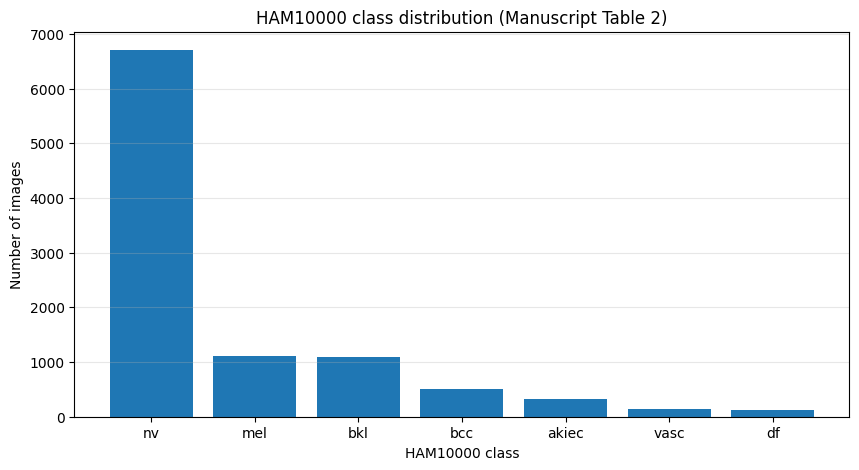

In [ ]:
class_counts = (
    df["dx"]
    .value_counts()
    .reindex(CLASS_ORDER)
    .rename_axis("class_code")
    .reset_index(name="count")
)
class_counts["class_name"] = class_counts["class_code"].map(CLASS_NAMES)
class_counts["percentage"] = 100 * class_counts["count"] / class_counts["count"].sum()
display(class_counts)

plt.figure(figsize=(10, 5))
plt.bar(class_counts["class_code"], class_counts["count"])
plt.xlabel("HAM10000 class")
plt.ylabel("Number of images")
plt.title("HAM10000 class distribution (Manuscript Table 2)")
plt.grid(axis="y", alpha=0.3)
plt.show()


## 8. Example images per class (Manuscript Figure 3)

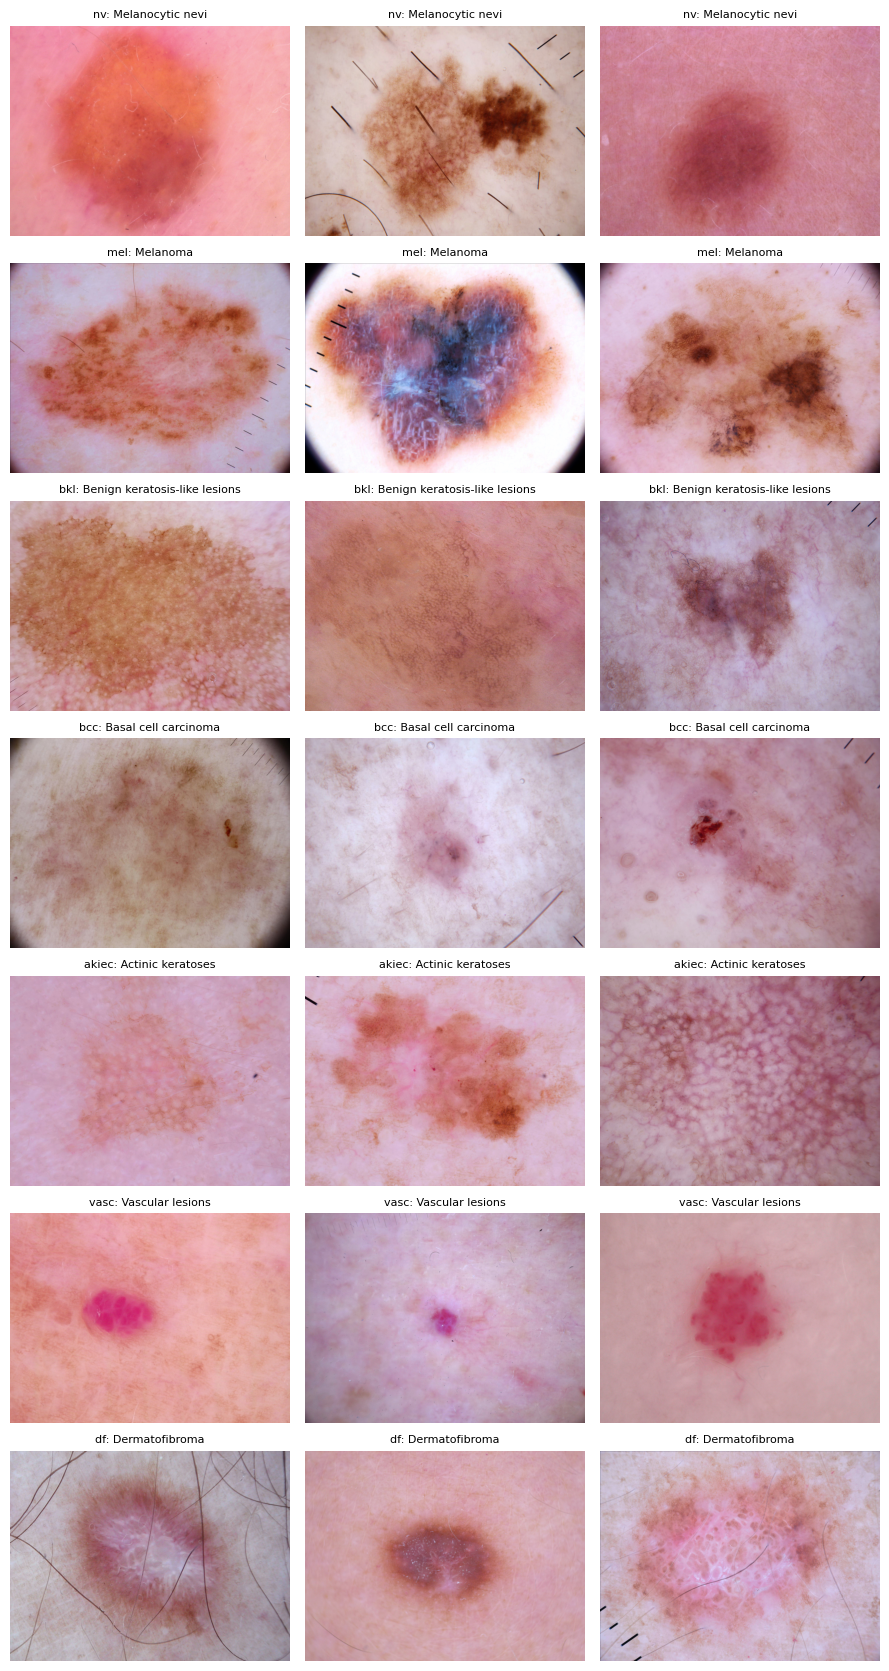

In [ ]:
def show_examples(df, n_per_class=3):
    fig, axes = plt.subplots(
        len(CLASS_ORDER), n_per_class,
        figsize=(3 * n_per_class, 2.4 * len(CLASS_ORDER)),
    )
    for row, cls in enumerate(CLASS_ORDER):
        subset = df[df["dx"] == cls].sample(
            min(n_per_class, (df["dx"] == cls).sum()), random_state=42
        )
        for col in range(n_per_class):
            ax = axes[row, col] if len(CLASS_ORDER) > 1 else axes[col]
            ax.axis("off")
            if col < len(subset):
                img = Image.open(subset.iloc[col]["image_path"]).convert("RGB")
                ax.imshow(img)
                ax.set_title(f"{cls}: {CLASS_NAMES[cls]}", fontsize=8)
    plt.tight_layout()
    plt.show()

show_examples(df, n_per_class=3)


## 9. Patient/lesion-aware 70:15:15 stratified split (Manuscript §5.2)

Manuscript §5.2:
> "The dataset will be split at the patient/lesion level ... into training,
>  validation, and test partitions in a 70:15:15 ratio, stratified by
>  diagnostic class so that the relative class proportions in Table 2 are
>  preserved within each partition."

We use `StratifiedGroupKFold` (group = `lesion_id`) so that no lesion appears
in more than one partition.


In [ ]:
def patient_level_split(df, test_size=0.15, val_size=0.15, seed=42):
    df = df.reset_index(drop=True).copy()

    if HAS_STRATIFIED_GROUP_KFOLD:
        # 1 fold of 7 gives ~14.3% test -- closest to 15%.
        sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=seed)
        y = df["label_idx"].values
        groups = df["lesion_id"].values
        train_val_idx, test_idx = next(sgkf.split(df, y, groups))
        train_val_df = df.iloc[train_val_idx].reset_index(drop=True)
        test_df = df.iloc[test_idx].reset_index(drop=True)

        # 1 fold of 6 over the remaining ~85.7% gives ~14.3% overall val.
        sgkf2 = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=seed + 1)
        y2 = train_val_df["label_idx"].values
        groups2 = train_val_df["lesion_id"].values
        train_idx2, val_idx2 = next(sgkf2.split(train_val_df, y2, groups2))

        train_df = train_val_df.iloc[train_idx2].reset_index(drop=True)
        val_df = train_val_df.iloc[val_idx2].reset_index(drop=True)
    else:
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        train_val_idx, test_idx = next(gss.split(df, groups=df["lesion_id"]))
        train_val_df = df.iloc[train_val_idx].reset_index(drop=True)
        test_df = df.iloc[test_idx].reset_index(drop=True)

        adjusted_val_size = val_size / (1.0 - test_size)
        gss2 = GroupShuffleSplit(
            n_splits=1, test_size=adjusted_val_size, random_state=seed + 1
        )
        train_idx2, val_idx2 = next(gss2.split(train_val_df, groups=train_val_df["lesion_id"]))
        train_df = train_val_df.iloc[train_idx2].reset_index(drop=True)
        val_df = train_val_df.iloc[val_idx2].reset_index(drop=True)

    return train_df, val_df, test_df


train_df, val_df, test_df = patient_level_split(
    df,
    test_size=CONFIG["TEST_SIZE"],
    val_size=CONFIG["VAL_SIZE"],
    seed=CONFIG["SPLIT_SEED"],
)

# Optional smoke-test sub-sample (debug/smoke profiles only).
if CONFIG.get("SMOKE_TEST"):
    print(f"SMOKE_TEST active -- capping each class to ~{CONFIG['SMOKE_MAX_IMAGES'] // 7} train samples.")
    train_df = (
        train_df.groupby("dx", group_keys=False)
        .apply(lambda x: x.sample(
            min(len(x), max(20, CONFIG["SMOKE_MAX_IMAGES"] // len(CLASS_ORDER))),
            random_state=42,
        ))
        .reset_index(drop=True)
    )
    val_df = (
        val_df.groupby("dx", group_keys=False)
        .apply(lambda x: x.sample(min(len(x), 50), random_state=43))
        .reset_index(drop=True)
    )
    test_df = (
        test_df.groupby("dx", group_keys=False)
        .apply(lambda x: x.sample(min(len(x), 50), random_state=44))
        .reset_index(drop=True)
    )

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

split_counts = pd.DataFrame({
    "train": train_df["dx"].value_counts().reindex(CLASS_ORDER),
    "val":   val_df["dx"].value_counts().reindex(CLASS_ORDER),
    "test":  test_df["dx"].value_counts().reindex(CLASS_ORDER),
}).fillna(0).astype(int)
display(split_counts)


def compute_balanced_class_weights(labels, num_classes=7, power=0.5):
    """Soft inverse-frequency class weights for imbalanced HAM10000 training.

    power=1.0 gives full inverse-frequency weighting; power=0.5 is safer for
    small/federated runs because it avoids over-correcting rare classes.
    """
    labels = np.asarray(labels, dtype=np.int64)
    counts = np.bincount(labels, minlength=num_classes).astype(np.float64)
    counts = np.maximum(counts, 1.0)
    weights = counts.sum() / (num_classes * counts)
    weights = np.power(weights, float(power))
    weights = weights / weights.mean()
    return weights.astype(np.float32)

GLOBAL_CLASS_WEIGHTS = torch.tensor(
    compute_balanced_class_weights(
        train_df["label_idx"].values,
        num_classes=CONFIG["NUM_CLASSES"],
        power=CONFIG.get("CLASS_WEIGHT_POWER", 0.5),
    ),
    dtype=torch.float32,
)
print("Global class weights used if USE_CLASS_WEIGHTED_LOSS=True:")
print(dict(zip(CLASS_ORDER, np.round(GLOBAL_CLASS_WEIGHTS.numpy(), 3))))

GLOBAL_CLASS_PRIOR = np.bincount(
    train_df["label_idx"].values,
    minlength=CONFIG["NUM_CLASSES"],
).astype(np.float64)
GLOBAL_CLASS_PRIOR = GLOBAL_CLASS_PRIOR / np.maximum(GLOBAL_CLASS_PRIOR.sum(), 1.0)
print("Global train class prior:")
print(dict(zip(CLASS_ORDER, np.round(GLOBAL_CLASS_PRIOR, 4))))


train_lesions = set(train_df["lesion_id"])
val_lesions = set(val_df["lesion_id"])
test_lesions = set(test_df["lesion_id"])
print("Train ∩ Val lesion overlap:", len(train_lesions & val_lesions))
print("Train ∩ Test lesion overlap:", len(train_lesions & test_lesions))
print("Val ∩ Test lesion overlap:", len(val_lesions & test_lesions))


Train: (7153, 10)
Val: (1431, 10)
Test: (1431, 10)


,train,val,test
dx,,,
nv,4789,958,958
mel,795,159,159
bkl,785,157,157
bcc,367,73,74
akiec,234,46,47
vasc,101,21,20
df,82,17,16


Global class weights used if USE_CLASS_WEIGHTED_LOSS=True:
{'nv': np.float32(0.245), 'mel': np.float32(0.601), 'bkl': np.float32(0.605), 'bcc': np.float32(0.884), 'akiec': np.float32(1.108), 'vasc': np.float32(1.686), 'df': np.float32(1.871)}
Global train class prior:
{'nv': np.float64(0.6695), 'mel': np.float64(0.1111), 'bkl': np.float64(0.1097), 'bcc': np.float64(0.0513), 'akiec': np.float64(0.0327), 'vasc': np.float64(0.0141), 'df': np.float64(0.0115)}
Train ∩ Val lesion overlap: 0
Train ∩ Test lesion overlap: 0
Val ∩ Test lesion overlap: 0


## 10. PyTorch Dataset and transforms (Manuscript §5.2)

Manuscript §5.2:
> "Each image will be resized to 224×224 pixels ... pixel intensities
>  normalized using channel-wise mean and standard deviation statistics.
>  Standard augmentation, including random horizontal and vertical flips,
>  small-angle rotation, and color-jitter, will be applied during local
>  client training ... validation and test images will be evaluated
>  without augmentation."


In [ ]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

_IMAGENET_MEAN = [0.485, 0.456, 0.406]
_IMAGENET_STD = [0.229, 0.224, 0.225]

if CONFIG.get("USE_STRONG_AUG", False):
    # Stronger but still safe augmentation for HAM10000 fine-tuning.
    # RandomResizedCrop makes the model less dependent on exact lesion position;
    # RandAugment adds mild color/contrast/geometry variation.
    _train_aug = [
        transforms.RandomResizedCrop(
            CONFIG["IMG_SIZE"], scale=(0.75, 1.0), ratio=(0.90, 1.10)
        ),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=20),
        transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.12, hue=0.02),
    ]
    try:
        _train_aug.append(transforms.RandAugment(num_ops=2, magnitude=7))
    except Exception:
        pass
else:
    _train_aug = [
        transforms.Resize((CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"])),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.08, contrast=0.08, saturation=0.08, hue=0.02),
    ]

_train_aug.extend([
    transforms.ToTensor(),
    transforms.Normalize(mean=_IMAGENET_MEAN, std=_IMAGENET_STD),
])

if CONFIG.get("USE_RANDOM_ERASING", False):
    _train_aug.append(transforms.RandomErasing(p=0.15, scale=(0.02, 0.08), ratio=(0.3, 3.3)))

train_tfms = transforms.Compose(_train_aug)

eval_tfms = transforms.Compose([
    transforms.Resize((CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=_IMAGENET_MEAN, std=_IMAGENET_STD),
])


class HAM10000Dataset(Dataset):
    """Lightweight dataset.

    Improvement over dataframe.iloc inside __getitem__:
    paths/labels are converted to arrays once, which noticeably reduces
    Python overhead in Colab when many client loaders are created.
    """
    def __init__(self, dataframe, transform=None):
        df_local = dataframe.reset_index(drop=True)
        self.paths = df_local["image_path"].astype(str).to_numpy()
        self.labels = df_local["label_idx"].astype(np.int64).to_numpy()
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, int(self.labels[idx])


def make_class_balanced_sampler(dataframe):
    """Return a WeightedRandomSampler using class frequency inside one client.

    This is optional. It helps minority classes and macro-F1, but it may slightly
    reduce top-line accuracy because HAM10000 is strongly imbalanced.
    """
    labels = dataframe["label_idx"].astype(np.int64).to_numpy()
    counts = np.bincount(labels, minlength=CONFIG["NUM_CLASSES"]).astype(np.float64)
    counts = np.maximum(counts, 1.0)
    sample_weights = 1.0 / counts[labels]
    sample_weights = torch.as_tensor(sample_weights, dtype=torch.double)
    return WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)


def make_loader(dataframe, transform, batch_size=None, shuffle=False, balanced_sampler=False):
    if batch_size is None:
        batch_size = CONFIG["BATCH_SIZE"]
    ds = HAM10000Dataset(dataframe, transform=transform)

    sampler = None
    if balanced_sampler:
        sampler = make_class_balanced_sampler(dataframe)
        shuffle = False

    loader_kwargs = dict(
        batch_size=batch_size,
        shuffle=shuffle if sampler is None else False,
        sampler=sampler,
        num_workers=CONFIG["NUM_WORKERS"],
        pin_memory=CONFIG.get("PIN_MEMORY", True) and torch.cuda.is_available(),
        drop_last=False,
    )

    # Only valid when num_workers > 0. Keeping workers off is usually safer
    # on Colab free/T4 for repeated client DataLoader creation.
    if CONFIG["NUM_WORKERS"] > 0:
        loader_kwargs["persistent_workers"] = CONFIG.get("PERSISTENT_WORKERS", True)
        loader_kwargs["prefetch_factor"] = CONFIG.get("PREFETCH_FACTOR", 2)

    return DataLoader(ds, **loader_kwargs)


val_loader = make_loader(val_df, eval_tfms, shuffle=False)
test_loader = make_loader(test_df, eval_tfms, shuffle=False)

print("Val batches:", len(val_loader), "Test batches:", len(test_loader))

Val batches: 90 Test batches: 90


## 11. Non-IID Dirichlet client partitioning (Manuscript §5.3)

Manuscript §5.3:
> "clients will receive a non-IID label allocation generated using a Dirichlet
>  distribution with concentration parameter α = 0.5, a configuration
>  consistent with established practice for simulating institutional
>  heterogeneity in healthcare federated learning [18]."


,client_id,n,nv,mel,bkl,bcc,akiec,vasc,df
0,0,1433,958,159,157,74,47,21,17
1,1,1432,958,159,157,74,47,20,17
2,2,1430,958,159,157,73,47,20,16
3,3,1430,958,159,157,73,47,20,16
4,4,1428,957,159,157,73,46,20,16


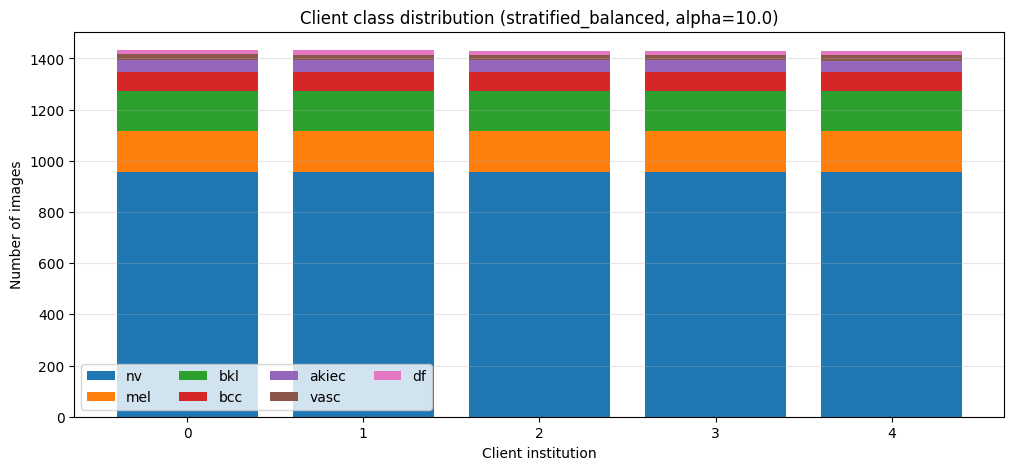

In [ ]:
def dirichlet_partition(dataframe, num_clients=10, alpha=0.5, seed=42, min_size=1):
    rng = np.random.default_rng(seed)
    labels = dataframe["label_idx"].values
    client_indices = [[] for _ in range(num_clients)]

    for class_idx in range(CONFIG["NUM_CLASSES"]):
        class_indices = np.where(labels == class_idx)[0]
        rng.shuffle(class_indices)

        proportions = rng.dirichlet(alpha=np.repeat(alpha, num_clients))
        cuts = (np.cumsum(proportions) * len(class_indices)).astype(int)[:-1]
        splits = np.split(class_indices, cuts)

        for client_id, split in enumerate(splits):
            client_indices[client_id].extend(split.tolist())

    for client_id in range(num_clients):
        rng.shuffle(client_indices[client_id])

    # Ensure no client is empty (only relevant in tiny smoke tests).
    for client_id in range(num_clients):
        if len(client_indices[client_id]) < min_size:
            largest = int(np.argmax([len(x) for x in client_indices]))
            if len(client_indices[largest]) > min_size:
                client_indices[client_id].append(client_indices[largest].pop())

    return client_indices


def stratified_balanced_partition(dataframe, num_clients=5, seed=42):
    """Near-IID client split with each class distributed across all clients.

    Use this only for clean high-accuracy experiments. For robustness/non-IID
    manuscript experiments, keep PARTITION_METHOD="dirichlet".
    """
    rng = np.random.default_rng(seed)
    labels = dataframe["label_idx"].values
    client_indices = [[] for _ in range(num_clients)]

    for class_idx in range(CONFIG["NUM_CLASSES"]):
        class_indices = np.where(labels == class_idx)[0]
        rng.shuffle(class_indices)
        splits = np.array_split(class_indices, num_clients)
        for client_id, split in enumerate(splits):
            client_indices[client_id].extend(split.tolist())

    for client_id in range(num_clients):
        rng.shuffle(client_indices[client_id])

    return client_indices


def make_client_indices(dataframe, seed=42):
    method = str(CONFIG.get("PARTITION_METHOD", "dirichlet"))
    if method == "stratified_balanced":
        return stratified_balanced_partition(
            dataframe,
            num_clients=CONFIG["NUM_CLIENTS"],
            seed=seed,
        )
    if method == "dirichlet":
        return dirichlet_partition(
            dataframe,
            num_clients=CONFIG["NUM_CLIENTS"],
            alpha=CONFIG["DIRICHLET_ALPHA"],
            seed=seed,
        )
    raise ValueError(f"Unknown PARTITION_METHOD={method}. Use 'dirichlet' or 'stratified_balanced'.")



client_indices = make_client_indices(train_df, seed=CONFIG["SPLIT_SEED"])

client_summary = []
for cid, idxs in enumerate(client_indices):
    sub = train_df.iloc[idxs]
    counts = sub["dx"].value_counts().reindex(CLASS_ORDER).fillna(0).astype(int)
    row = {"client_id": cid, "n": len(sub)}
    row.update(counts.to_dict())
    client_summary.append(row)

client_summary_df = pd.DataFrame(client_summary)
display(client_summary_df)

plt.figure(figsize=(12, 5))
bottom = np.zeros(len(client_summary_df))
x = client_summary_df["client_id"].astype(str)
for cls in CLASS_ORDER:
    plt.bar(x, client_summary_df[cls], bottom=bottom, label=cls)
    bottom += client_summary_df[cls].values
plt.xlabel("Client institution")
plt.ylabel("Number of images")
plt.title(f"Client class distribution ({CONFIG.get('PARTITION_METHOD', 'dirichlet')}, alpha={CONFIG.get('DIRICHLET_ALPHA', None)})")
plt.legend(ncol=4)
plt.grid(axis="y", alpha=0.3)
plt.show()


## 12. Label-flipping poisoning attack (Manuscript §4.4 + §5.4)

Manuscript §4.4:
> "ỹⱼ = target class, with probability ρ; ỹⱼ = yⱼ, otherwise ... where the
>  target class is fixed for the duration of training and ρ controls flip
>  intensity."

Manuscript §5.4:
> "relabeling malignant categories (melanoma, basal cell carcinoma, actinic
>  keratoses) as the majority benign class with flip probability ρ = 1.0
>  applied to their entire local partition."


In [ ]:
def poison_client_dataframe(client_df, flip_prob=1.0, seed=42):
    rng = np.random.default_rng(seed)
    poisoned = client_df.copy()
    y = poisoned["label_idx"].values.copy()

    malignant_mask = np.isin(y, MALIGNANT_IDXS)
    flip_mask = malignant_mask & (rng.random(len(y)) < flip_prob)

    y[flip_mask] = TARGET_BENIGN_IDX
    poisoned["original_label_idx"] = poisoned["label_idx"].values
    poisoned["label_idx"] = y.astype(int)
    poisoned["is_flipped"] = flip_mask.astype(int)

    return poisoned


# Demonstration on client 0
demo_client = train_df.iloc[client_indices[0]].copy()
demo_poisoned = poison_client_dataframe(demo_client, flip_prob=1.0, seed=42)
print("Demo flipped labels:", int(demo_poisoned["is_flipped"].sum()))
display(pd.crosstab(
    demo_client["dx"],
    demo_poisoned["label_idx"].map(IDX_TO_CLASS),
    rownames=["Original"], colnames=["Poisoned"],
))


Demo flipped labels: 280


Poisoned,bkl,df,nv,vasc
Original,,,,
akiec,0,0,47,0
bcc,0,0,74,0
bkl,157,0,0,0
df,0,17,0,0
mel,0,0,159,0
nv,0,0,958,0
vasc,0,0,0,21


## 13. Fed-ResViT hybrid architecture (Manuscript §4.2)

Manuscript §4.2:
> "The convolutional stream applies a ResNet-50 backbone [22],
>  F_cnn = ResNet50(x) ∈ ℝ^{H'×W'×C} ... The global-context stream first
>  partitions x into fixed-size, non-overlapping patches, linearly embeds
>  each patch, and adds a learned positional encoding, following the
>  original Vision Transformer formulation [23] ... processed through L
>  Transformer encoder blocks, each computing multi-head self-attention ...
>
>  The pooled convolutional feature vector and the aggregated ViT token
>  representation are concatenated and passed through a fusion projection
>  layer with a non-linear activation and dropout regularization, producing
>  a fused feature vector h. A final linear classification head with softmax
>  activation maps h to a probability distribution over the seven HAM10000
>  diagnostic categories."

For the paper-full profile we use `vit_base_patch16_224` (the canonical ViT
of Dosovitskiy et al. [23]) so the comparison to hybrid CNN-ViT works in
§2.2 (e.g. GlobalSkinNet) is on the same backbone class.


In [ ]:
class FedResViT(nn.Module):
    def __init__(
        self,
        num_classes=7,
        vit_backbone="vit_base_patch16_224",
        fusion_dim=512,
        dropout=0.3,
        resnet_pretrained=True,
        vit_pretrained=True,
        freeze_backbones=False,
    ):
        super().__init__()

        # ---- CNN stream: ResNet-50 (Sec 4.2, ref [22]) ----
        try:
            from torchvision.models import ResNet50_Weights
            weights = ResNet50_Weights.IMAGENET1K_V2 if resnet_pretrained else None
            self.cnn = resnet50(weights=weights)
        except Exception as e:
            print("ResNet pretrained load failed. Falling back to random init:", repr(e))
            self.cnn = resnet50(weights=None)

        cnn_in = self.cnn.fc.in_features
        self.cnn.fc = nn.Identity()

        # ---- ViT stream (Sec 4.2, ref [23]) ----
        try:
            self.vit = timm.create_model(
                vit_backbone, pretrained=vit_pretrained, num_classes=0
            )
        except Exception as e:
            print("ViT pretrained load failed. Falling back to random init:", repr(e))
            self.vit = timm.create_model(
                vit_backbone, pretrained=False, num_classes=0
            )

        vit_dim = self.vit.num_features

        if freeze_backbones:
            for p in self.cnn.parameters():
                p.requires_grad = False
            for p in self.vit.parameters():
                p.requires_grad = False

            # Accuracy-oriented partial fine-tuning:
            # keep most pretrained features frozen but allow the final semantic
            # layers to adapt to dermoscopic lesions. This is much lighter than
            # full backpropagation through ResNet-50 + ViT.
            if CONFIG.get("UNFREEZE_RESNET_LAYER3", False) and hasattr(self.cnn, "layer3"):
                for p in self.cnn.layer3.parameters():
                    p.requires_grad = True

            if CONFIG.get("UNFREEZE_RESNET_LAYER4", False) and hasattr(self.cnn, "layer4"):
                for p in self.cnn.layer4.parameters():
                    p.requires_grad = True

            n_vit = int(CONFIG.get("UNFREEZE_VIT_LAST_N_BLOCKS", 0) or 0)
            if n_vit > 0 and hasattr(self.vit, "blocks"):
                for block in self.vit.blocks[-n_vit:]:
                    for p in block.parameters():
                        p.requires_grad = True

            if CONFIG.get("UNFREEZE_VIT_NORM", False) and hasattr(self.vit, "norm"):
                for p in self.vit.norm.parameters():
                    p.requires_grad = True

        # ---- Fusion + classifier (Sec 4.2) ----
        self.fusion = nn.Sequential(
            nn.Linear(cnn_in + vit_dim, fusion_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, num_classes),
        )

        # Optional classifier-prior initialization.
        # This only sets the initial bias and can speed convergence on imbalanced HAM10000.
        if CONFIG.get("INIT_CLASSIFIER_BIAS", False) and "GLOBAL_CLASS_PRIOR" in globals():
            try:
                prior = np.asarray(GLOBAL_CLASS_PRIOR, dtype=np.float32)
                prior = np.clip(prior, 1e-6, 1.0)
                bias = torch.log(torch.tensor(prior / prior.sum(), dtype=torch.float32))
                with torch.no_grad():
                    self.fusion[-1].bias.copy_(bias)
                print("Initialized classifier bias from train-set class prior.")
            except Exception as e:
                print("Classifier bias prior initialization skipped:", repr(e))

    def forward(self, x):
        local_feat = self.cnn(x)          # CNN stream
        global_feat = self.vit(x)         # ViT stream
        fused = torch.cat([local_feat, global_feat], dim=1)
        logits = self.fusion(fused)
        return logits


def build_model():
    model = FedResViT(
        num_classes=CONFIG["NUM_CLASSES"],
        vit_backbone=CONFIG["VIT_BACKBONE"],
        fusion_dim=CONFIG["FUSION_DIM"],
        dropout=CONFIG["DROPOUT"],
        resnet_pretrained=CONFIG["RESNET_PRETRAINED"],
        vit_pretrained=CONFIG["VIT_PRETRAINED"],
        freeze_backbones=CONFIG["FREEZE_BACKBONES"],
    )
    if CONFIG.get("USE_CHANNELS_LAST", False) and DEVICE.type == "cuda":
        model = model.to(memory_format=torch.channels_last)
    return model


# Smoke check
model = build_model().to(DEVICE)
x = torch.randn(2, 3, CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"]).to(DEVICE)
with torch.no_grad():
    y = model(x)
print("Output shape:", y.shape)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
del model, x, y
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 190MB/s]


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Initialized classifier bias from train-set class prior.
Output shape: torch.Size([2, 7])
Total parameters: 47,047,623
Trainable parameters: 31,035,655


## 14. Metrics (Manuscript §5.5)

Manuscript §5.5:
> "Diagnostic performance will be reported using macro-averaged accuracy,
>  precision, recall (sensitivity), F1-score, and specificity across the
>  seven diagnostic classes ... Adversarial robustness will be quantified
>  using four metrics standard in the federated learning security literature
>  [13], [17], [18]: Attack Success Rate (ASR), defined as the proportion
>  of malignant test samples successfully relabeled as benign by the
>  poisoned global model; global model accuracy under attack;
>  malicious-client detection rate, defined as the proportion of designated
>  malicious clients whose trust weight φ(Δᵢ) falls below a flagging
>  threshold within a fixed number of rounds; and false-positive rate,
>  defined as the proportion of benign clients incorrectly flagged as
>  malicious."


In [ ]:
def compute_specificity_macro(y_true, y_pred, num_classes=7):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    specificities = []
    for c in range(num_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        tn = cm.sum() - tp - fp - fn
        denom = tn + fp
        spec = tn / denom if denom > 0 else np.nan
        specificities.append(spec)
    return float(np.nanmean(specificities))


def compute_asr(y_true, y_pred):
    '''ASR (Sec 5.5): proportion of malignant test samples predicted as the
    benign target class by the poisoned global model.'''
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    malignant_mask = np.isin(y_true, MALIGNANT_IDXS)
    if malignant_mask.sum() == 0:
        return np.nan
    return float(np.mean(y_pred[malignant_mask] == TARGET_BENIGN_IDX))


def compute_malignant_safety(y_true, y_pred):
    asr = compute_asr(y_true, y_pred)
    if np.isnan(asr):
        return np.nan
    return float(1.0 - asr)


def compute_metrics(y_true, y_pred, prefix=""):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred,
        labels=list(range(CONFIG["NUM_CLASSES"])),
        average="macro", zero_division=0,
    )
    specificity = compute_specificity_macro(y_true, y_pred, num_classes=CONFIG["NUM_CLASSES"])
    asr = compute_asr(y_true, y_pred)
    malignant_safety = compute_malignant_safety(y_true, y_pred)

    return {
        f"{prefix}accuracy": float(acc),
        f"{prefix}macro_precision": float(precision),
        f"{prefix}macro_recall": float(recall),
        f"{prefix}macro_f1": float(f1),
        f"{prefix}macro_specificity": float(specificity),
        f"{prefix}asr": float(asr) if not np.isnan(asr) else np.nan,
        f"{prefix}malignant_safety": float(malignant_safety) if not np.isnan(malignant_safety) else np.nan,
    }


## 15. Cross-entropy (and optional focal loss) — Manuscript §4.2

Manuscript §4.2:
> "The model is trained to minimize categorical cross-entropy between ŷ and
>  the ground-truth label, optionally replaced by a focal loss formulation
>  [21] to mitigate the substantial class imbalance documented in Table 2."

We keep class weights off by default (the manuscript does not mention class
weighting; it mentions only focal loss as the imbalance-mitigation mechanism).
Set `USE_FOCAL_LOSS=True` for the focal variant.


In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma = float(gamma)
        self.weight = weight

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.weight, reduction="none")
        pt = torch.exp(-ce)
        loss = ((1.0 - pt) ** self.gamma) * ce
        return loss.mean()


## 16. Local training and evaluation

Manuscript §5.3:
> "Adam optimizer with an initial learning rate of 1×10⁻⁴ and a batch size of 32."

Each client runs `E = 3` local epochs per round on its own partition.


In [ ]:
def cleanup_memory():
    """Release Python and CUDA cached memory between clients/rounds."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass

def freeze_batchnorm_stats(model):
    """Keep BatchNorm running_mean/running_var fixed during federated fine-tuning.

    This matters in FL because each client has a small and often non-IID batch
    distribution. Averaging client-specific BatchNorm running stats can harm
    validation accuracy even when the train loss decreases.
    """
    for module in model.modules():
        if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d, nn.SyncBatchNorm)):
            module.eval()
            for p in module.parameters():
                p.requires_grad = False


def round_learning_rate(round_idx, num_rounds):
    base_lr = float(CONFIG["LR"])

    # Linear warmup: several profiles unfreeze many pretrained layers at once
    # (ResNet layer3/layer4 + several ViT blocks). Hitting all of those with
    # the full target LR on round 1 tends to cause a rough start that the
    # federated averaging never fully recovers from -- a warmup avoids that.
    warmup_rounds = int(CONFIG.get("LR_WARMUP_ROUNDS", 0) or 0)
    if warmup_rounds > 0 and round_idx <= warmup_rounds:
        warmup_lr = base_lr * (round_idx / float(warmup_rounds))
        return max(warmup_lr, base_lr * 0.05)

    schedule = str(CONFIG.get("ROUND_LR_SCHEDULE", "constant")).lower()
    if schedule != "cosine":
        return base_lr

    min_mult = float(CONFIG.get("MIN_LR_MULT", 0.10))
    # Progress is measured over the post-warmup rounds so the cosine curve
    # still spans the full remaining schedule instead of being compressed.
    remaining_rounds = max(num_rounds - warmup_rounds, 1)
    progress = (round_idx - warmup_rounds - 1) / max(remaining_rounds - 1, 1)
    progress = min(max(progress, 0.0), 1.0)
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    return base_lr * (min_mult + (1.0 - min_mult) * cosine)



def train_local_model(
    model,
    loader,
    local_epochs=1,
    lr=1e-4,
    weight_decay=0.0,
    device=DEVICE,
    max_batches=None,
):
    """Train one local client model.

    max_batches is used only for quick Colab-safe runs. Keep it None for
    manuscript/final results.
    """
    model.train()
    if CONFIG.get("FREEZE_BATCHNORM_STATS", False):
        freeze_batchnorm_stats(model)

    trainable_params = [p for p in model.parameters() if p.requires_grad]
    if len(trainable_params) == 0:
        raise RuntimeError("No trainable parameters found. Check FREEZE_BACKBONES/fusion settings.")

    # Differential learning rate:
    # the fusion head can learn faster, while partially unfrozen pretrained
    # backbone layers use a smaller LR to prevent catastrophic forgetting.
    if hasattr(model, "fusion"):
        fusion_param_ids = {id(p) for p in model.fusion.parameters() if p.requires_grad}
        fusion_params = [p for p in model.fusion.parameters() if p.requires_grad]
        backbone_params = [p for p in trainable_params if id(p) not in fusion_param_ids]
        param_groups = []
        if len(backbone_params) > 0:
            param_groups.append({
                "params": backbone_params,
                "lr": lr * float(CONFIG.get("BACKBONE_LR_MULT", 0.2)),
                "weight_decay": weight_decay,
            })
        if len(fusion_params) > 0:
            param_groups.append({
                "params": fusion_params,
                "lr": lr,
                "weight_decay": weight_decay,
            })
    else:
        param_groups = [{"params": trainable_params, "lr": lr, "weight_decay": weight_decay}]

    if CONFIG.get("OPTIMIZER", "adam") == "adam":
        optimizer = torch.optim.Adam(param_groups)
    else:
        optimizer = torch.optim.AdamW(param_groups)

    label_smoothing = float(CONFIG.get("LABEL_SMOOTHING", 0.0) or 0.0)

    if CONFIG.get("USE_FOCAL_LOSS", False):
        criterion = FocalLoss(gamma=CONFIG.get("FOCAL_GAMMA", 2.0))
    elif CONFIG.get("USE_CLASS_WEIGHTED_LOSS", False):
        # Uses clean global train distribution, not poisoned client labels.
        # This improves macro-F1 stability in small Colab runs without changing
        # the federated aggregation logic.
        criterion = nn.CrossEntropyLoss(
            weight=GLOBAL_CLASS_WEIGHTS.to(device), label_smoothing=label_smoothing
        )
    else:
        criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    use_amp = CONFIG["USE_AMP"] and device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    total_loss = 0.0
    total_count = 0

    for _ in range(local_epochs):
        for batch_idx, (images, labels) in enumerate(loader):
            if max_batches is not None and batch_idx >= max_batches:
                break

            images = images.to(device, non_blocking=True)
            if CONFIG.get("USE_CHANNELS_LAST", False) and device.type == "cuda":
                images = images.to(memory_format=torch.channels_last)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=use_amp):
                logits = model(images)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=5.0)
            scaler.step(optimizer)
            scaler.update()

            bs = images.size(0)
            total_loss += float(loss.detach().item()) * bs
            total_count += bs

            # reduce temporary GPU references before the next batch
            del images, labels, logits, loss

    return total_loss / max(total_count, 1)


@torch.inference_mode()
def evaluate_model(model, loader, device=DEVICE, max_batches=None):
    model.eval()
    y_true, y_pred, y_prob = [], [], []

    use_amp = CONFIG.get("USE_AMP", False) and device.type == "cuda"
    for batch_idx, (images, labels) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break
        images = images.to(device, non_blocking=True)
        if CONFIG.get("USE_CHANNELS_LAST", False) and device.type == "cuda":
            images = images.to(memory_format=torch.channels_last)

        with torch.amp.autocast("cuda", enabled=use_amp):
            logits = model(images)
            probs = torch.softmax(logits, dim=1)

            # Optional test-time augmentation. Horizontal flip averaging is
            # cheap and often improves clean HAM10000 accuracy slightly.
            if CONFIG.get("TTA_EVAL", False):
                logits_flip = model(torch.flip(images, dims=[3]))
                probs_flip = torch.softmax(logits_flip, dim=1)
                probs = 0.5 * (probs + probs_flip)
                del logits_flip, probs_flip

        preds = torch.argmax(probs, dim=1)

        y_true.extend(labels.cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())
        y_prob.extend(probs.detach().cpu().numpy().tolist())

        del images, logits, probs, preds

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)
    metrics = compute_metrics(y_true, y_pred)
    return metrics, y_true, y_pred, y_prob

## 17. Aggregation utilities (Manuscript §4.5, Algorithm 1)

This is the **manuscript-faithful** implementation of the trust-aware
aggregator. Key points:

1. The reference update `w_ref` is the **geometric median** of client
   updates — *not* the coordinate-wise median. We use Weiszfeld's
   iterative algorithm.
2. The distance `Δᵢ = ‖wᵢ − w_ref‖₂` is the **Euclidean** (L2) distance,
   unnormalised.
3. The soft-trust function `φ(Δᵢ)` uses **fixed** thresholds `T_low` and
   `T_high` (no adaptive MAD/quantile thresholds, no auto-tuning).
4. The reputation `rᵢ` is updated by momentum with parameter `ρ_m`:
   `rᵢ^(t+1) = ρ_m · rᵢ^(t) + (1 − ρ_m) · φ(Δᵢ^(t))`.
5. The aggregate is the **trust-weighted average**:
   `w_g = Σ rᵢ·φ(Δᵢ)·wᵢ / Σ rᵢ·φ(Δᵢ)`.
6. There is **no validation blending**, no min-weight floor, no
   ever-flagged bookkeeping. Detection-rate / FPR are computed from
   "φ(Δᵢ) < flag_threshold within `TRUST_FLAG_ROUNDS` rounds" per §5.5.

These are the deltas `wᵢ = local_state − global_state_before_round`, exactly
as the manuscript intends (each client starts each round from the same global
weights `w_g^(t)`).


In [ ]:
def clone_state_dict(state_dict):
    """Detach a state dict and move it to CPU."""
    return {k: v.detach().cpu().clone() for k, v in state_dict.items()}


def is_float_tensor(t):
    return torch.is_tensor(t) and torch.is_floating_point(t)


def subtract_state_dict(local_state, base_state):
    """Return local_state - base_state for floating tensors."""
    delta = {}
    for k in base_state.keys():
        if is_float_tensor(base_state[k]):
            delta[k] = local_state[k].float() - base_state[k].float()
        else:
            delta[k] = base_state[k].clone()
    return delta


def add_delta_to_state(base_state, delta_state):
    """Return base_state + delta_state for floating tensors."""
    out = {}
    for k in base_state.keys():
        if is_float_tensor(base_state[k]):
            out[k] = (base_state[k].float() + delta_state[k].float()).to(dtype=base_state[k].dtype)
        else:
            out[k] = base_state[k].clone()
    return out


def aggregate_weighted_average(states, weights):
    """Weighted average over state dicts or delta dicts."""
    weights = np.asarray(weights, dtype=np.float64)
    total_w = float(np.sum(weights))
    if total_w <= 1e-12:
        weights = np.ones(len(states), dtype=np.float64)
        total_w = float(np.sum(weights))

    out = {}
    for k in states[0].keys():
        first = states[0][k]
        if is_float_tensor(first):
            acc = torch.zeros_like(first, dtype=torch.float32)
            for state, w in zip(states, weights):
                acc += state[k].float() * float(w)
            out[k] = (acc / total_w).to(dtype=first.dtype)
        else:
            out[k] = first.clone()
    return out


# ---------------------------------------------------------------------------
# FedAvg (Manuscript ref [9])
# ---------------------------------------------------------------------------
def aggregate_fedavg_delta(client_deltas, client_sizes):
    return aggregate_weighted_average(client_deltas, np.asarray(client_sizes, dtype=np.float64))


# ---------------------------------------------------------------------------
# Krum (Manuscript ref [10])
# ---------------------------------------------------------------------------
def state_distance_sq(a, b, normalize=False):
    """Squared L2 distance between two state/delta dictionaries.
    normalize=False keeps the raw L2 norm (matches manuscript Sec 4.5)."""
    total = 0.0
    for k in a.keys():
        if is_float_tensor(a[k]):
            diff = a[k].float() - b[k].float()
            total += float(torch.sum(diff * diff).item())
    return total


def aggregate_krum_delta(client_deltas, f=0):
    """Krum: select the single client update whose sum of distances to its
    m = n - f - 2 nearest neighbours is smallest."""
    n = len(client_deltas)
    if n <= 2:
        return clone_state_dict(client_deltas[0])

    f = int(max(0, min(f, n - 2)))
    m = max(1, n - f - 2)

    distances = np.zeros((n, n), dtype=np.float64)
    for i in range(n):
        for j in range(i + 1, n):
            d = state_distance_sq(client_deltas[i], client_deltas[j], normalize=False)
            distances[i, j] = d
            distances[j, i] = d

    scores = []
    for i in range(n):
        nearest = np.sort(distances[i][distances[i] > 0])[:m]
        scores.append(nearest.sum() if len(nearest) > 0 else 0.0)

    selected = int(np.argmin(scores))
    return clone_state_dict(client_deltas[selected])


# ---------------------------------------------------------------------------
# Coordinate-wise trimmed mean (Manuscript ref [11])
# ---------------------------------------------------------------------------
def aggregate_trimmed_mean_delta(client_deltas, trim_ratio=0.2):
    n = len(client_deltas)
    trim_k = int(math.floor(trim_ratio * n))
    if 2 * trim_k >= n:
        trim_k = max(0, (n - 1) // 2)

    out = {}
    for k in client_deltas[0].keys():
        first = client_deltas[0][k]
        if is_float_tensor(first):
            stacked = torch.stack([s[k].float() for s in client_deltas], dim=0)
            sorted_vals, _ = torch.sort(stacked, dim=0)
            trimmed = sorted_vals[trim_k:n - trim_k] if trim_k > 0 else sorted_vals
            out[k] = trimmed.mean(dim=0).to(dtype=first.dtype)
        else:
            out[k] = first.clone()
    return out


# ---------------------------------------------------------------------------
# Geometric median via Weiszfeld iteration (Manuscript Sec 4.5)
# ---------------------------------------------------------------------------
def aggregate_geometric_median(client_deltas, max_iters=10, eps=1e-6):
    """Geometric median over client deltas via Weiszfeld's algorithm.

    Returns a state-delta dict approximating
        argmin_x  sum_i || x - d_i ||_2

    We initialise from the coordinate-wise mean (a robust-ish start),
    then iterate:
        x_{t+1} = sum_i (d_i / ||d_i - x_t||) / sum_i (1 / ||d_i - x_t||)
    and stop after `max_iters` or when the relative change is below `eps`.
    """
    n = len(client_deltas)
    if n == 0:
        raise ValueError("Cannot take geometric median of zero deltas.")
    if n == 1:
        return clone_state_dict(client_deltas[0])

    # Initialise x_0 = coordinate-wise mean.
    x = aggregate_weighted_average(client_deltas, np.ones(n, dtype=np.float64))

    float_keys = [k for k in x.keys() if is_float_tensor(x[k])]

    def l2_dist(d1, d2):
        total = 0.0
        for k in float_keys:
            diff = d1[k].float() - d2[k].float()
            total += float(torch.sum(diff * diff).item())
        return math.sqrt(max(total, 0.0))

    for it in range(max_iters):
        # Compute weights 1 / ||d_i - x_t|| (with eps floor).
        ws = np.zeros(n, dtype=np.float64)
        for i in range(n):
            d = l2_dist(client_deltas[i], x)
            ws[i] = 1.0 / max(d, eps)

        if ws.sum() <= 0:
            break

        x_new = {}
        for k in x.keys():
            if not is_float_tensor(x[k]):
                x_new[k] = x[k].clone()
                continue
            acc = torch.zeros_like(x[k], dtype=torch.float32)
            for i in range(n):
                acc += client_deltas[i][k].float() * float(ws[i])
            x_new[k] = (acc / float(ws.sum())).to(dtype=x[k].dtype)

        # Check convergence.
        change = l2_dist(x_new, x)
        x = x_new
        if change < eps:
            break

    return x



# ---------------------------------------------------------------------------
# Trust-aware aggregator -- memory-safe + numerically stable distance option.
# ---------------------------------------------------------------------------
class TrustAwareAggregator:
    """Trust-aware aggregation.

    Two practical improvements are included:

    1) TRUST_DISTANCE_MODE="rms" computes L2/sqrt(parameter_count). Raw L2 over
       millions of parameters is often too large for fixed thresholds and may
       drive every phi to zero.

    2) TRUST_ADAPTIVE_THRESHOLDS=True uses median/MAD-based thresholds per round.
       This prevents the all-zero-trust collapse in small Colab runs. Disable it
       if you need the exact fixed-threshold manuscript version.
    """

    def __init__(
        self,
        num_clients,
        t_low,
        t_high,
        momentum=0.85,
        flag_phi_threshold=0.5,
        flag_rounds=5,
        geom_median_iters=10,
        distance_mode="rms",
        adaptive_thresholds=True,
        mad_low_mult=0.5,
        mad_high_mult=3.0,
    ):
        self.num_clients = int(num_clients)
        self.t_low = float(t_low)
        self.t_high = float(t_high)
        self.momentum = float(momentum)
        self.flag_phi_threshold = float(flag_phi_threshold)
        self.flag_rounds = int(flag_rounds)
        self.geom_median_iters = int(geom_median_iters)
        self.distance_mode = str(distance_mode).lower()
        self.adaptive_thresholds = bool(adaptive_thresholds)
        self.mad_low_mult = float(mad_low_mult)
        self.mad_high_mult = float(mad_high_mult)

        if self.t_high <= self.t_low:
            raise ValueError("T_high must be > T_low.")
        if self.distance_mode not in {"l2", "rms"}:
            raise ValueError("distance_mode must be 'l2' or 'rms'.")

        self.reputation = np.ones(self.num_clients, dtype=np.float64)
        self.phi_history = defaultdict(list)
        self.rounds_seen = 0

    @staticmethod
    def _phi(delta, t_low, t_high):
        if delta <= t_low:
            return 1.0
        if delta >= t_high:
            return 0.0
        return float((t_high - delta) / max(t_high - t_low, 1e-12))

    def _distance(self, a, b):
        total = 0.0
        n_params = 0
        for k in a.keys():
            if is_float_tensor(a[k]):
                diff = a[k].float() - b[k].float()
                total += float(torch.sum(diff * diff).item())
                n_params += diff.numel()
        dist = math.sqrt(max(total, 0.0))
        if self.distance_mode == "rms":
            dist = dist / math.sqrt(max(n_params, 1))
        return dist

    def _round_thresholds(self, distances):
        if not self.adaptive_thresholds or len(distances) < 3:
            return self.t_low, self.t_high

        distances = np.asarray(distances, dtype=np.float64)
        med = float(np.median(distances))
        mad = float(np.median(np.abs(distances - med)))

        # If MAD collapses to zero, fall back to an IQR/percentile scale.
        if mad <= 1e-12:
            q25, q75 = np.percentile(distances, [25, 75])
            spread = float(max(q75 - q25, np.std(distances), 1e-12))
        else:
            spread = 1.4826 * mad  # robust sigma estimate

        t_low = med + self.mad_low_mult * spread
        t_high = med + self.mad_high_mult * spread
        if t_high <= t_low:
            t_high = t_low + max(abs(t_low) * 0.1, 1e-8)

        return float(t_low), float(t_high)

    def aggregate(self, client_deltas, client_sizes):
        w_ref = aggregate_geometric_median(
            client_deltas, max_iters=self.geom_median_iters
        )

        distances = np.zeros(len(client_deltas), dtype=np.float64)
        for i, d in enumerate(client_deltas):
            distances[i] = self._distance(d, w_ref)

        round_t_low, round_t_high = self._round_thresholds(distances)

        phi = np.zeros(len(client_deltas), dtype=np.float64)
        for i in range(len(client_deltas)):
            phi[i] = self._phi(distances[i], round_t_low, round_t_high)

        self.reputation = (
            self.momentum * self.reputation + (1.0 - self.momentum) * phi
        )
        self.rounds_seen += 1

        for i in range(len(client_deltas)):
            self.phi_history[i].append(phi[i])
            if len(self.phi_history[i]) > self.flag_rounds:
                self.phi_history[i].pop(0)

        flagged_now = np.zeros(len(client_deltas), dtype=bool)
        for i in range(len(client_deltas)):
            hist = self.phi_history[i]
            if hist and min(hist) < self.flag_phi_threshold:
                flagged_now[i] = True

        weights = self.reputation * phi

        if weights.sum() <= 1e-12:
            print("All trust weights are zero this round; falling back to FedAvg-delta.")
            weights = np.asarray(client_sizes, dtype=np.float64)

        aggregated_delta = aggregate_weighted_average(client_deltas, weights)

        info = {
            "distances": distances,
            "phi": phi,
            "reputation": self.reputation.copy(),
            "weights": weights.copy(),
            "flagged_now": flagged_now.copy(),
            "distance_mode": self.distance_mode,
            "round_t_low": round_t_low,
            "round_t_high": round_t_high,
            "w_ref_norm": float(np.linalg.norm(distances)),
        }
        return aggregated_delta, info


## 18. Federated experiment runner

For each (seed, malicious_fraction, aggregation_method) combination we:
1. Build a Dirichlet partition of `train_df` (Sec 5.3).
2. Pick `malicious_fraction · K` malicious clients (Sec 5.4).
3. Run T rounds of federated training; in each round every client trains
   E local epochs on its (possibly poisoned) partition, sends its delta
   to the server, and the server aggregates using the chosen method.
4. Evaluate the final global model on `test_df` and record all §5.5 metrics.


In [ ]:
def make_client_dataframes(train_df, client_indices, malicious_clients=None, seed=42):
    if malicious_clients is None:
        malicious_clients = set()

    client_dfs = []
    poison_stats = []

    for cid, idxs in enumerate(client_indices):
        client_df = train_df.iloc[idxs].copy().reset_index(drop=True)
        if cid in malicious_clients:
            client_df = poison_client_dataframe(
                client_df, flip_prob=CONFIG["FLIP_PROB"], seed=seed + cid
            )
            flipped = int(client_df["is_flipped"].sum())
        else:
            client_df["original_label_idx"] = client_df["label_idx"].values
            client_df["is_flipped"] = 0
            flipped = 0

        client_dfs.append(client_df)
        poison_stats.append({
            "client_id": cid,
            "is_malicious": cid in malicious_clients,
            "n": len(client_df),
            "flipped_labels": flipped,
            "flip_rate_within_client": flipped / max(len(client_df), 1),
        })

    return client_dfs, pd.DataFrame(poison_stats)


def choose_malicious_clients(num_clients, malicious_fraction, seed=42):
    rng = np.random.default_rng(seed)
    n_mal = int(round(num_clients * malicious_fraction))
    n_mal = min(max(n_mal, 0), num_clients)
    if n_mal == 0:
        return set()
    return set(rng.choice(num_clients, size=n_mal, replace=False).tolist())


def detection_metrics(flagged, malicious_clients, num_clients):
    '''Detection rate = TP / (#malicious); FPR = FP / (#benign).'''
    flagged = np.asarray(flagged).astype(bool)
    malicious_mask = np.array(
        [i in malicious_clients for i in range(num_clients)], dtype=bool
    )

    if malicious_mask.sum() > 0:
        detection_rate = float(np.mean(flagged[malicious_mask]))
    else:
        detection_rate = np.nan
    benign_mask = ~malicious_mask
    if benign_mask.sum() > 0:
        false_positive_rate = float(np.mean(flagged[benign_mask]))
    else:
        false_positive_rate = np.nan
    return detection_rate, false_positive_rate


def _clean_asr_if_no_attack(metrics, malicious_fraction):
    '''ASR is only defined under attack (Sec 5.5).'''
    metrics = dict(metrics)
    if malicious_fraction == 0:
        metrics["asr"] = np.nan
        metrics["malignant_safety"] = np.nan
    return metrics


def _safe_model_filename(aggregation_method, malicious_fraction, seed):
    mal_tag = str(malicious_fraction).replace(".", "p")
    return f"{aggregation_method}_mal{mal_tag}_seed{seed}.pt"


def _weighted_delta_accumulate(acc, delta, weight):
    """Streaming FedAvg helper: avoids storing all client deltas in RAM."""
    if acc is None:
        out = {}
        for k, v in delta.items():
            if is_float_tensor(v):
                out[k] = v.float() * float(weight)
            else:
                out[k] = v.clone()
        return out
    for k, v in delta.items():
        if is_float_tensor(v):
            acc[k] += v.float() * float(weight)
    return acc


def _finalize_weighted_delta(acc, total_weight):
    out = {}
    total_weight = max(float(total_weight), 1e-12)
    for k, v in acc.items():
        if is_float_tensor(v):
            out[k] = (v.float() / total_weight).to(dtype=v.dtype)
        else:
            out[k] = v.clone()
    return out


def run_federated_experiment(
    aggregation_method="trust",
    malicious_fraction=0.2,
    seed=42,
    num_rounds=None,
    local_epochs=None,
):
    set_seed(seed)

    if num_rounds is None:
        num_rounds = CONFIG["NUM_ROUNDS"]
    if local_epochs is None:
        local_epochs = CONFIG["LOCAL_EPOCHS"]

    client_indices = make_client_indices(train_df, seed=seed)

    malicious_clients = choose_malicious_clients(
        CONFIG["NUM_CLIENTS"], malicious_fraction, seed=seed + 1000,
    )

    client_dfs, poison_stats = make_client_dataframes(
        train_df, client_indices, malicious_clients=malicious_clients, seed=seed,
    )
    client_sizes = [len(cdf) for cdf in client_dfs]

    global_model = build_model().to(DEVICE)
    global_state = clone_state_dict(global_model.state_dict())

    # Reuse one local model, but do not keep all client DataLoaders alive.
    local_model = build_model().to(DEVICE)

    trust_agg = None
    if aggregation_method == "trust":
        trust_agg = TrustAwareAggregator(
            num_clients=CONFIG["NUM_CLIENTS"],
            t_low=CONFIG["TRUST_T_LOW"],
            t_high=CONFIG["TRUST_T_HIGH"],
            momentum=CONFIG["TRUST_MOMENTUM"],
            flag_phi_threshold=CONFIG["TRUST_FLAG_PHI_THRESHOLD"],
            flag_rounds=CONFIG["TRUST_FLAG_ROUNDS"],
            geom_median_iters=CONFIG["TRUST_GEOM_MEDIAN_ITERS"],
            distance_mode=CONFIG.get("TRUST_DISTANCE_MODE", "rms"),
            adaptive_thresholds=CONFIG.get("TRUST_ADAPTIVE_THRESHOLDS", True),
            mad_low_mult=CONFIG.get("TRUST_MAD_LOW_MULT", 0.5),
            mad_high_mult=CONFIG.get("TRUST_MAD_HIGH_MULT", 3.0),
        )

    history = []
    last_trust_info = None
    best_state = None
    best_round = None
    best_metric_value = -np.inf
    best_metric_name = str(CONFIG.get("BEST_MODEL_METRIC", "accuracy"))

    print("=" * 90)
    print(f"Aggregator: {aggregation_method} | malicious_fraction={malicious_fraction} | seed={seed}")
    print("Malicious clients:", sorted(malicious_clients))
    display(poison_stats)

    for round_idx in range(1, num_rounds + 1):
        round_start = time.time()
        base_state = clone_state_dict(global_state)
        current_lr = round_learning_rate(round_idx, num_rounds)
        train_losses = []
        detection_rate_current = np.nan
        false_positive_rate_current = np.nan

        # For FedAvg, stream the weighted average so RAM does not hold every full update.
        fedavg_acc = None
        fedavg_weight = 0.0
        client_deltas = [] if aggregation_method != "fedavg" else None

        for cid, client_df in enumerate(tqdm(
            client_dfs, desc=f"Round {round_idx}/{num_rounds}", leave=False
        )):
            loader = make_loader(
                client_df, train_tfms,
                batch_size=CONFIG["BATCH_SIZE"],
                shuffle=True,
                balanced_sampler=CONFIG.get("USE_CLIENT_BALANCED_SAMPLER", False),
            )

            local_model.load_state_dict(base_state, strict=True)

            loss = train_local_model(
                local_model, loader,
                local_epochs=local_epochs,
                lr=current_lr,
                weight_decay=CONFIG["WEIGHT_DECAY"],
                device=DEVICE,
                max_batches=CONFIG.get("MAX_TRAIN_BATCHES_PER_CLIENT", None),
            )

            local_state = clone_state_dict(local_model.state_dict())
            client_delta = subtract_state_dict(local_state, base_state)
            train_losses.append(loss)

            if aggregation_method == "fedavg":
                fedavg_acc = _weighted_delta_accumulate(
                    fedavg_acc, client_delta, client_sizes[cid]
                )
                fedavg_weight += float(client_sizes[cid])
                del local_state, client_delta
            else:
                client_deltas.append(client_delta)
                del local_state

            del loader
            if CONFIG.get("CLEAR_CUDA_EACH_CLIENT", False):
                cleanup_memory()

        if aggregation_method == "fedavg":
            aggregated_delta = _finalize_weighted_delta(fedavg_acc, fedavg_weight)
            del fedavg_acc

        elif aggregation_method == "krum":
            f = len(malicious_clients)
            aggregated_delta = aggregate_krum_delta(client_deltas, f=f)

        elif aggregation_method == "trimmed_mean":
            aggregated_delta = aggregate_trimmed_mean_delta(
                client_deltas, trim_ratio=CONFIG["TRIM_RATIO"]
            )

        elif aggregation_method == "trust":
            aggregated_delta, last_trust_info = trust_agg.aggregate(
                client_deltas, client_sizes
            )
            detection_rate_current, false_positive_rate_current = detection_metrics(
                last_trust_info["flagged_now"], malicious_clients, CONFIG["NUM_CLIENTS"]
            )

        else:
            raise ValueError(f"Unknown aggregation method: {aggregation_method}")

        if client_deltas is not None:
            del client_deltas

        global_state = add_delta_to_state(base_state, aggregated_delta)
        global_model.load_state_dict(global_state, strict=True)
        del base_state, aggregated_delta
        cleanup_memory()

        if (round_idx % CONFIG.get("EVAL_EVERY", 1) == 0) or (round_idx == num_rounds):
            val_metrics, _, _, _ = evaluate_model(
                global_model, val_loader, DEVICE,
                max_batches=CONFIG.get("MAX_VAL_BATCHES", None),
            )
            val_metrics = _clean_asr_if_no_attack(val_metrics, malicious_fraction)
        else:
            val_metrics = {
                "accuracy": np.nan,
                "macro_precision": np.nan,
                "macro_recall": np.nan,
                "macro_f1": np.nan,
                "macro_specificity": np.nan,
                "asr": np.nan,
                "malignant_safety": np.nan,
            }

        # Keep the best validation checkpoint. This is important for high-accuracy
        # runs because the final FL round is not always the best generalizing round.
        if CONFIG.get("USE_BEST_VAL_MODEL", False):
            metric_value = val_metrics.get(best_metric_name, np.nan)
            if (
                round_idx >= int(CONFIG.get("BEST_MODEL_MIN_ROUND", 1))
                and metric_value is not None
                and not np.isnan(metric_value)
                and float(metric_value) > float(best_metric_value)
            ):
                if best_state is not None:
                    del best_state
                best_state = clone_state_dict(global_state)
                best_metric_value = float(metric_value)
                best_round = int(round_idx)

        elapsed = time.time() - round_start
        row = {
            "seed": seed,
            "round": round_idx,
            "aggregation": aggregation_method,
            "malicious_fraction": malicious_fraction,
            "num_malicious": len(malicious_clients),
            "malicious_clients": sorted(list(malicious_clients)),
            "avg_train_loss": float(np.mean(train_losses)),
            "round_lr": float(current_lr),
            "round_seconds": elapsed,
            "detection_rate_current": detection_rate_current,
            "false_positive_rate_current": false_positive_rate_current,
        }
        row.update({f"val_{k}": v for k, v in val_metrics.items()})

        if last_trust_info is not None:
            row.update({
                "trust_mean_phi": float(np.mean(last_trust_info["phi"])),
                "trust_min_phi": float(np.min(last_trust_info["phi"])),
                "trust_mean_reputation": float(np.mean(last_trust_info["reputation"])),
                "trust_min_reputation": float(np.min(last_trust_info["reputation"])),
                "trust_num_flagged_now": int(np.sum(last_trust_info["flagged_now"])),
                "trust_distance_mode": last_trust_info.get("distance_mode", ""),
                "trust_round_t_low": float(last_trust_info.get("round_t_low", np.nan)),
                "trust_round_t_high": float(last_trust_info.get("round_t_high", np.nan)),
            })

        history.append(row)

        asr_print = "NA (no attack)" if np.isnan(row["val_asr"]) and malicious_fraction == 0 else ("NA" if np.isnan(row["val_asr"]) else f"{row['val_asr']:.4f}")
        best_text = ""
        if CONFIG.get("USE_BEST_VAL_MODEL", False) and best_round is not None:
            best_text = f" | best_{best_metric_name}=round{best_round}:{best_metric_value:.4f}"
        print(
            f"Round {round_idx:03d} | loss={row['avg_train_loss']:.4f} | lr={current_lr:.2e} | "
            f"val_acc={row['val_accuracy']:.4f} | val_f1={row['val_macro_f1']:.4f} | "
            f"ASR={asr_print}{best_text} | time={elapsed:.1f}s"
        )

        if last_trust_info is not None:
            print(
                "  dist:", np.round(last_trust_info["distances"], 6),
                "thr:", (round(last_trust_info.get("round_t_low", np.nan), 6),
                        round(last_trust_info.get("round_t_high", np.nan), 6)),
                "phi:", np.round(last_trust_info["phi"], 3),
                "rep:", np.round(last_trust_info["reputation"], 3),
                "flag_now:", last_trust_info["flagged_now"].astype(int),
            )

    del local_model
    cleanup_memory()

    if CONFIG.get("USE_BEST_VAL_MODEL", False) and best_state is not None:
        print(f"Using best validation checkpoint from round {best_round} "
              f"({best_metric_name}={best_metric_value:.4f}) for final test.")
        global_state = best_state
        global_model.load_state_dict(global_state, strict=True)

    test_metrics, y_true, y_pred, y_prob = evaluate_model(
        global_model, test_loader, DEVICE,
        max_batches=CONFIG.get("MAX_TEST_BATCHES", None),
    )
    test_metrics = _clean_asr_if_no_attack(test_metrics, malicious_fraction)

    result = {
        "seed": seed,
        "aggregation": aggregation_method,
        "malicious_fraction": malicious_fraction,
        "num_malicious": len(malicious_clients),
        "malicious_clients": sorted(list(malicious_clients)),
        "best_val_round": best_round,
        f"best_val_{best_metric_name}": best_metric_value if best_round is not None else np.nan,
    }
    result.update({f"test_{k}": v for k, v in test_metrics.items()})

    if last_trust_info is not None:
        final_det, final_fpr = detection_metrics(
            last_trust_info["flagged_now"], malicious_clients, CONFIG["NUM_CLIENTS"]
        )
        result["test_detection_rate"] = final_det
        result["test_false_positive_rate"] = final_fpr
        result["trust_final_phi"] = np.round(last_trust_info["phi"], 6).tolist()
        result["trust_final_reputation"] = np.round(last_trust_info["reputation"], 6).tolist()
    else:
        result["test_detection_rate"] = np.nan
        result["test_false_positive_rate"] = np.nan
        result["trust_final_phi"] = None
        result["trust_final_reputation"] = None

    model_name = _safe_model_filename(aggregation_method, malicious_fraction, seed)
    model_path = os.path.join(CONFIG["OUTPUT_DIR"], model_name)
    if CONFIG.get("SAVE_MODEL_CHECKPOINTS", True):
        torch.save(global_state, model_path)
        result["model_path"] = model_path
    else:
        result["model_path"] = "not_saved_low_memory_mode"

    # Save predictions to disk so large arrays do not need to stay in memory.
    prediction_path = os.path.join(CONFIG["OUTPUT_DIR"], model_name.replace(".pt", "_predictions.npz"))
    if CONFIG.get("SAVE_PREDICTIONS_TO_DISK", True):
        np.savez_compressed(
            prediction_path,
            y_true=y_true.astype(np.int64),
            y_pred=y_pred.astype(np.int64),
            y_prob=y_prob.astype(np.float32),
        )
        result["prediction_path"] = prediction_path
    else:
        result["prediction_path"] = ""

    report = classification_report(
        y_true, y_pred,
        labels=list(range(CONFIG["NUM_CLASSES"])),
        target_names=[CLASS_NAMES[c] for c in CLASS_ORDER],
        zero_division=0, output_dict=True,
    )
    report_df = pd.DataFrame(report).T
    report_name = model_name.replace(".pt", "_classification_report.csv")
    report_path = os.path.join(CONFIG["OUTPUT_DIR"], report_name)
    report_df.to_csv(report_path)
    result["classification_report_path"] = report_path

    del global_model
    cleanup_memory()

    output = {
        "result": result,
        "history": pd.DataFrame(history),
        "poison_stats": poison_stats,
        "classification_report": report_df,
    }

    if CONFIG.get("SAVE_RUN_ARTIFACTS_IN_MEMORY", False):
        output.update({
            "y_true": y_true,
            "y_pred": y_pred,
            "y_prob": y_prob,
        })
    else:
        # Keep only compact metadata in memory.
        del y_true, y_pred, y_prob

    return output


## 19. Centralized upper-bound baseline (Manuscript §5.4)

Manuscript §5.4:
> "A fully centralized, non-federated Fed-ResViT model trained on the pooled,
>  unpartitioned, attack-free training set will additionally be trained as an
>  upper-bound reference, following the practice used in prior federated
>  healthcare security studies [18]."


In [ ]:
def run_centralized_baseline(seed=42, epochs=15):
    set_seed(seed)
    train_loader = make_loader(
        train_df, train_tfms, batch_size=CONFIG["BATCH_SIZE"], shuffle=True
    )
    model = build_model().to(DEVICE)

    history = []
    for epoch in range(1, epochs + 1):
        loss = train_local_model(
            model, train_loader,
            local_epochs=1,
            lr=CONFIG["LR"],
            weight_decay=CONFIG["WEIGHT_DECAY"],
            device=DEVICE,
            max_batches=CONFIG.get("MAX_TRAIN_BATCHES_PER_CLIENT", None),
        )
        val_metrics, _, _, _ = evaluate_model(
            model, val_loader, DEVICE,
            max_batches=CONFIG.get("MAX_VAL_BATCHES", None),
        )
        val_metrics["asr"] = np.nan
        val_metrics["malignant_safety"] = np.nan
        row = {"epoch": epoch, "loss": loss}
        row.update({f"val_{k}": v for k, v in val_metrics.items()})
        history.append(row)
        print(
            f"Epoch {epoch:03d} | loss={loss:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | val_f1={val_metrics['macro_f1']:.4f}"
        )

    test_metrics, y_true, y_pred, y_prob = evaluate_model(
        model, test_loader, DEVICE,
        max_batches=CONFIG.get("MAX_TEST_BATCHES", None),
    )
    test_metrics["asr"] = np.nan
    test_metrics["malignant_safety"] = np.nan
    return model, pd.DataFrame(history), test_metrics, y_true, y_pred, y_prob


centralized_result_row = None
if CONFIG["RUN_CENTRALIZED_BASELINE"]:
    centralized_model, centralized_history, centralized_test_metrics, c_y_true, c_y_pred, c_y_prob = (
        run_centralized_baseline(seed=CONFIG["SPLIT_SEED"], epochs=CONFIG["CENTRALIZED_EPOCHS"])
    )
    centralized_result_row = {
        "seed": CONFIG["SPLIT_SEED"],
        "aggregation": "centralized_upper_bound",
        "malicious_fraction": 0.0,
        "num_malicious": 0,
        "malicious_clients": [],
    }
    centralized_result_row.update({f"test_{k}": v for k, v in centralized_test_metrics.items()})
    print(centralized_test_metrics)
    # Do not keep a full centralized model in GPU/CPU memory after recording results.
    del centralized_model
    cleanup_memory()


### Optimization note
This optimized copy keeps the original Fed-ResViT logic but reduces runtime by:

- using a `paper_fast` profile by default for quick execution;
- reusing a single local client model instead of rebuilding ResNet+ViT for every client;
- enabling faster DataLoader settings (`persistent_workers`, `prefetch_factor`, `pin_memory`);
- enabling CUDA benchmark/TF32 where available;
- allowing validation every `EVAL_EVERY` rounds for exploratory runs.

For final manuscript numbers, change `EXPERIMENT_PROFILE` back to `paper_full` and use the full protocol.

**Colab-safe update:** this copy defaults to `EXPERIMENT_PROFILE = "colab_safe"`, which uses a smaller ViT, smaller batch size, fewer clients, no persistent DataLoader workers, and streaming FedAvg aggregation to prevent runtime crashes. Use it for checking the pipeline only; switch to `paper_fast`/`paper_full` for final reported numbers.


## 20. Run federated experiments

Runs every (seed × malicious_fraction × aggregator) combination specified by
the active profile. With `paper_full` this is 5 seeds × 4 malicious fractions
× 4 aggregators = **80 federated runs**, each 50 rounds × 10 clients × 3
local epochs. Plan for substantial GPU time.


In [ ]:
all_results = []
all_histories = []

results_csv = os.path.join(CONFIG["OUTPUT_DIR"], "fedresvit_results.csv")
history_csv = os.path.join(CONFIG["OUTPUT_DIR"], "fedresvit_round_history.csv")
partial_results_csv = os.path.join(CONFIG["OUTPUT_DIR"], "fedresvit_results_partial.csv")
partial_history_csv = os.path.join(CONFIG["OUTPUT_DIR"], "fedresvit_round_history_partial.csv")

completed_keys = set()

# Resume from partial files if a previous Colab session crashed.
if CONFIG.get("RESUME_FROM_PARTIAL", True) and os.path.exists(partial_results_csv):
    try:
        prev_results = pd.read_csv(partial_results_csv)
        if len(prev_results) > 0:
            all_results.extend(prev_results.to_dict("records"))
            for _, r in prev_results.iterrows():
                if r.get("aggregation") != "centralized_upper_bound":
                    completed_keys.add((
                        int(r["seed"]),
                        float(r["malicious_fraction"]),
                        str(r["aggregation"]),
                    ))
            print(f"Resume mode: found {len(completed_keys)} completed FL runs.")
    except Exception as e:
        print("Could not load partial results; starting fresh:", repr(e))

if CONFIG.get("RESUME_FROM_PARTIAL", True) and os.path.exists(partial_history_csv):
    try:
        prev_hist = pd.read_csv(partial_history_csv)
        if len(prev_hist) > 0:
            all_histories.append(prev_hist)
    except Exception as e:
        print("Could not load partial history:", repr(e))

if centralized_result_row is not None:
    # Avoid duplicate centralized rows when resuming.
    if not any(str(r.get("aggregation")) == "centralized_upper_bound" for r in all_results):
        all_results.append(centralized_result_row)

for seed in CONFIG["SEEDS"]:
    for malicious_fraction in CONFIG["MALICIOUS_FRACTIONS"]:
        for agg in CONFIG["AGGREGATORS"]:
            run_key = (int(seed), float(malicious_fraction), str(agg))
            if run_key in completed_keys:
                print(f"Skipping completed run: seed={seed}, mal={malicious_fraction}, agg={agg}")
                continue

            output = run_federated_experiment(
                aggregation_method=agg,
                malicious_fraction=malicious_fraction,
                seed=seed,
                num_rounds=CONFIG["NUM_ROUNDS"],
                local_epochs=CONFIG["LOCAL_EPOCHS"],
            )

            all_results.append(output["result"])

            hist = output["history"].copy()
            hist["seed"] = seed
            hist["aggregation"] = agg
            hist["malicious_fraction"] = malicious_fraction
            all_histories.append(hist)

            # Save after every run. If Colab crashes later, completed runs are preserved.
            results_df_partial = pd.DataFrame(all_results)
            history_df_partial = pd.concat(all_histories, ignore_index=True) if len(all_histories) else pd.DataFrame()
            results_df_partial.to_csv(partial_results_csv, index=False)
            history_df_partial.to_csv(partial_history_csv, index=False)
            completed_keys.add(run_key)

            # Drop large local references immediately.
            del output, hist, results_df_partial, history_df_partial
            cleanup_memory()

results_df = pd.DataFrame(all_results)
history_df = pd.concat(all_histories, ignore_index=True) if len(all_histories) else pd.DataFrame()

results_df.to_csv(results_csv, index=False)
history_df.to_csv(history_csv, index=False)

print("Saved results:", results_csv)
print("Saved history:", history_csv)
print("Saved partial results:", partial_results_csv)
display(results_df)

Initialized classifier bias from train-set class prior.
Initialized classifier bias from train-set class prior.
Aggregator: fedavg | malicious_fraction=0.0 | seed=42
Malicious clients: []


,client_id,is_malicious,n,flipped_labels,flip_rate_within_client
0,0,False,1433,0,0.0
1,1,False,1432,0,0.0
2,2,False,1430,0,0.0
3,3,False,1430,0,0.0
4,4,False,1428,0,0.0


Round 1/30:   0%|          | 0/5 [00:00<?, ?it/s]

Round 001 | loss=0.9952 | lr=6.67e-05 | val_acc=0.7184 | val_f1=0.2754 | ASR=NA (no attack) | time=247.5s


Round 2/30:   0%|          | 0/5 [00:00<?, ?it/s]

...

Round 29/30:   0%|          | 0/5 [00:00<?, ?it/s]

Round 029 | loss=0.4325 | lr=1.07e-05 | val_acc=0.8148 | val_f1=0.6484 | ASR=0.2698 | best_accuracy=round11:0.8204 | time=134.8s
  dist: [2.7e-05 2.8e-05 2.7e-05 5.8e-05 2.7e-05] thr: (2.7e-05, 2.7e-05) phi: [1. 0. 1. 0. 1.] rep: [0.998 0.734 0.998 0.02  0.998] flag_now: [0 1 0 1 0]


Round 30/30:   0%|          | 0/5 [00:00<?, ?it/s]

Round 030 | loss=0.4432 | lr=1.00e-05 | val_acc=0.8127 | val_f1=0.6437 | ASR=0.2662 | best_accuracy=round11:0.8204 | time=135.3s
  dist: [2.5e-05 2.6e-05 2.5e-05 5.8e-05 2.5e-05] thr: (2.5e-05, 2.6e-05) phi: [1.    0.236 1.    0.    1.   ] rep: [0.998 0.66  0.998 0.017 0.998] flag_now: [0 1 0 1 0]
Using best validation checkpoint from round 11 (accuracy=0.8204) for final test.
Saved results: /content/fedresvit_outputs_manuscript/fedresvit_results.csv
Saved history: /content/fedresvit_outputs_manuscript/fedresvit_round_history.csv
Saved partial results: /content/fedresvit_outputs_manuscript/fedresvit_results_partial.csv


,seed,aggregation,malicious_fraction,num_malicious,malicious_clients,best_val_round,best_val_accuracy,test_accuracy,test_macro_precision,test_macro_recall,...,test_macro_specificity,test_asr,test_malignant_safety,test_detection_rate,test_false_positive_rate,trust_final_phi,trust_final_reputation,model_path,prediction_path,classification_report_path
0,42,fedavg,0.0,0,[],17,0.816911,0.823201,0.722612,0.625993,...,0.950660,NaN,NaN,NaN,NaN,None,None,/content/fedresvit_outputs_manuscript/fedavg_m...,/content/fedresvit_outputs_manuscript/fedavg_m...,/content/fedresvit_outputs_manuscript/fedavg_m...
1,42,trust,0.0,0,[],22,0.819706,0.831586,0.723454,0.617631,...,0.953865,NaN,NaN,NaN,0.20,"[0.0, 0.930204, 1.0, 1.0, 1.0]","[0.611642, 0.896463, 0.943693, 0.98952, 0.977121]",/content/fedresvit_outputs_manuscript/trust_ma...,/content/fedresvit_outputs_manuscript/trust_ma...,/content/fedresvit_outputs_manuscript/trust_ma...
2,42,fedavg,0.2,1,[3],17,0.812020,0.812718,0.747276,0.602079,...,0.941473,0.364286,0.635714,NaN,NaN,None,None,/content/fedresvit_outputs_manuscript/fedavg_m...,/content/fedresvit_outputs_manuscript/fedavg_m...,/content/fedresvit_outputs_manuscript/fedavg_m...
3,42,trust,0.2,1,[3],21,0.822502,0.827393,0.736889,0.623053,...,0.950729,0.264286,0.735714,1.0,0.25,"[0.784165, 1.0, 1.0, 0.0, 1.0]","[0.871952, 0.999766, 0.994201, 0.020564, 0.999...",/content/fedresvit_outputs_manuscript/trust_ma...,/content/fedresvit_outputs_manuscript/trust_ma...,/content/fedresvit_outputs_manuscript/trust_ma...
4,43,fedavg,0.0,0,[],11,0.823201,0.823899,0.698572,0.602826,...,0.952910,NaN,NaN,NaN,NaN,None,None,/content/fedresvit_outputs_manuscript/fedavg_m...,/content/fedresvit_outputs_manuscript/fedavg_m...,/content/fedresvit_outputs_manuscript/fedavg_m...
5,43,trust,0.0,0,[],11,0.821104,0.823899,0.713083,0.617115,...,0.953067,NaN,NaN,NaN,0.20,"[1.0, 0.930204, 1.0, 0.736701, 1.0]","[0.80177, 0.916263, 0.962205, 0.842228, 0.954451]",/content/fedresvit_outputs_manuscript/trust_ma...,/content/fedresvit_outputs_manuscript/trust_ma...,/content/fedresvit_outputs_manuscript/trust_ma...
6,43,fedavg,0.2,1,[3],26,0.809224,0.812020,0.749416,0.576264,...,0.940579,0.375000,0.625000,NaN,NaN,None,None,/content/fedresvit_outputs_manuscript/fedavg_m...,/content/fedresvit_outputs_manuscript/fedavg_m...,/content/fedresvit_outputs_manuscript/fedavg_m...
7,43,trust,0.2,1,[3],11,0.820405,0.824598,0.698775,0.628767,...,0.953382,0.214286,0.785714,1.0,0.25,"[1.0, 0.235572, 1.0, 0.0, 1.0]","[0.998048, 0.659543, 0.997941, 0.017168, 0.998...",/content/fedresvit_outputs_manuscript/trust_ma...,/content/fedresvit_outputs_manuscript/trust_ma...,/content/fedresvit_outputs_manuscript/trust_ma...


## 21. Results summary tables (Manuscript Tables 3 & 4)

`mean ± SD` across the 5 seeds (one value if a single seed).


In [ ]:
metric_cols = [
    "test_accuracy",
    "test_macro_precision",
    "test_macro_recall",
    "test_macro_f1",
    "test_macro_specificity",
    "test_malignant_safety",
    "test_asr",
    "test_detection_rate",
    "test_false_positive_rate",
]
metric_cols = [c for c in metric_cols if c in results_df.columns]


def mean_std_text(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    if len(x) == 0:
        return "—"
    if len(x) == 1:
        return f"{x.iloc[0]:.4f}"
    return f"{x.mean():.4f} ± {x.std(ddof=1):.4f}"


summary = (
    results_df
    .groupby(["malicious_fraction", "aggregation"], dropna=False)[metric_cols]
    .agg(mean_std_text)
    .reset_index()
)
display(summary)

summary_csv = os.path.join(CONFIG["OUTPUT_DIR"], "fedresvit_summary_mean_std.csv")
summary.to_csv(summary_csv, index=False)
print("Saved summary:", summary_csv)

# Table 3: clean classification
clean_table = summary[summary["malicious_fraction"] == 0.0].copy()
clean_csv = os.path.join(CONFIG["OUTPUT_DIR"], "table_clean_classification.csv")
clean_table.to_csv(clean_csv, index=False)
print("Saved clean table:", clean_csv)

# Table 4: attack robustness
attack_table = summary[summary["malicious_fraction"] > 0.0].copy()
attack_csv = os.path.join(CONFIG["OUTPUT_DIR"], "table_attack_robustness.csv")
attack_table.to_csv(attack_csv, index=False)
print("Saved attack table:", attack_csv)


,malicious_fraction,aggregation,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_macro_specificity,test_malignant_safety,test_asr,test_detection_rate,test_false_positive_rate
0,0.0,fedavg,0.8235 ± 0.0005,0.7106 ± 0.0170,0.6144 ± 0.0164,0.6488 ± 0.0213,0.9518 ± 0.0016,—,—,—,—
1,0.0,trust,0.8277 ± 0.0054,0.7183 ± 0.0073,0.6174 ± 0.0004,0.6543 ± 0.0060,0.9535 ± 0.0006,—,—,—,0.2000 ± 0.0000
2,0.2,fedavg,0.8124 ± 0.0005,0.7483 ± 0.0015,0.5892 ± 0.0183,0.6377 ± 0.0127,0.9410 ± 0.0006,0.6304 ± 0.0076,0.3696 ± 0.0076,—,—
3,0.2,trust,0.8260 ± 0.0020,0.7178 ± 0.0270,0.6259 ± 0.0040,0.6596 ± 0.0124,0.9521 ± 0.0019,0.7607 ± 0.0354,0.2393 ± 0.0354,1.0000 ± 0.0000,0.2500 ± 0.0000


Saved summary: /content/fedresvit_outputs_manuscript/fedresvit_summary_mean_std.csv
Saved clean table: /content/fedresvit_outputs_manuscript/table_clean_classification.csv
Saved attack table: /content/fedresvit_outputs_manuscript/table_attack_robustness.csv


## 22. Convergence curves (Manuscript Figure 5)

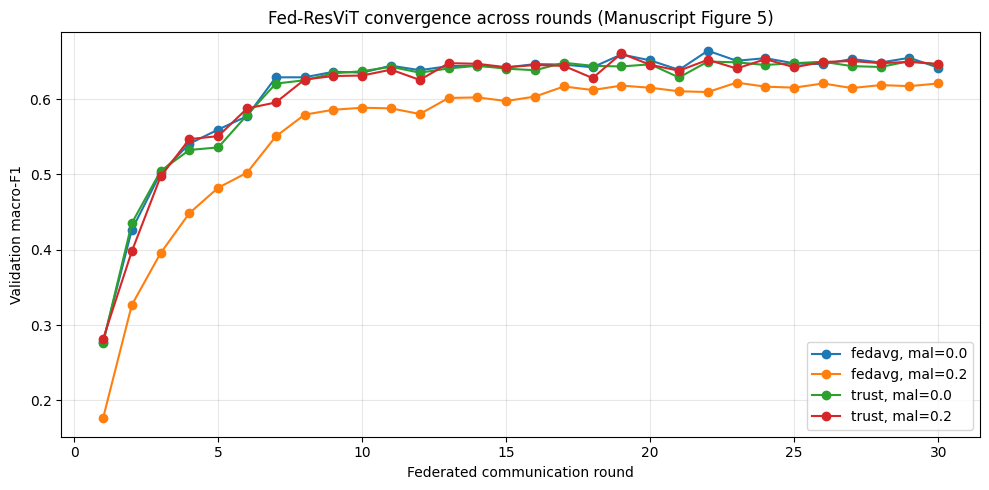

Saved figure: /content/fedresvit_outputs_manuscript/figure_convergence_macro_f1.png


In [ ]:
if not history_df.empty:
    plt.figure(figsize=(10, 5))
    for (agg, mal), sub in history_df.groupby(["aggregation", "malicious_fraction"]):
        label = f"{agg}, mal={mal}"
        sub_mean = sub.groupby("round")["val_macro_f1"].mean()
        plt.plot(sub_mean.index, sub_mean.values, marker="o", label=label)
    plt.xlabel("Federated communication round")
    plt.ylabel("Validation macro-F1")
    plt.title("Fed-ResViT convergence across rounds (Manuscript Figure 5)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    fig_path = os.path.join(CONFIG["OUTPUT_DIR"], "figure_convergence_macro_f1.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved figure:", fig_path)
else:
    print("No history available to plot.")


## 23. Confusion matrix for a selected run (Manuscript Figure 6)

Selected saved prediction file: /content/fedresvit_outputs_manuscript/trust_mal0p2_seed43_predictions.npz


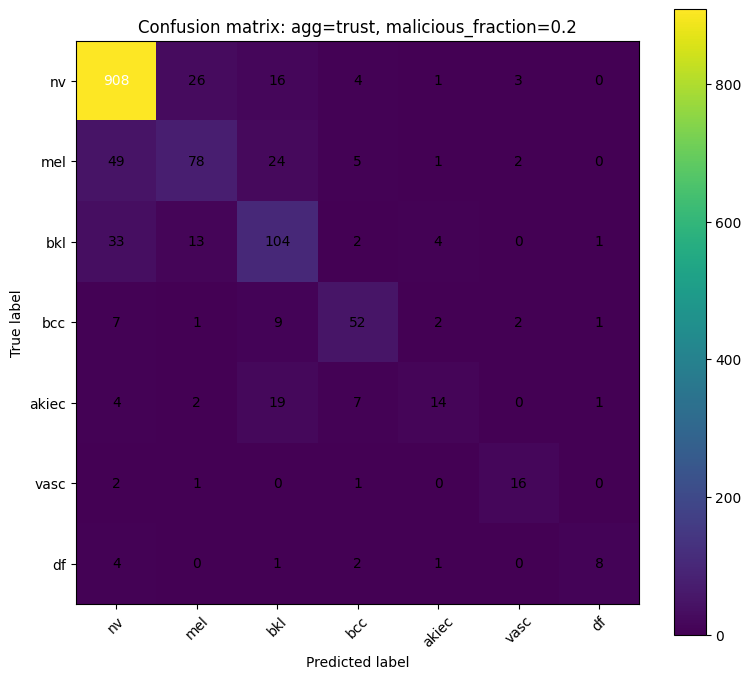

Saved confusion matrix: /content/fedresvit_outputs_manuscript/figure_confusion_matrix_trust_mal0p2_seed43.png


,precision,recall,f1-score,support
Melanocytic nevi,0.901688,0.947808,0.924173,958.000000
Melanoma,0.644628,0.490566,0.557143,159.000000
Benign keratosis-like lesions,0.601156,0.662420,0.630303,157.000000
Basal cell carcinoma,0.712329,0.702703,0.707483,74.000000
Actinic keratoses,0.608696,0.297872,0.400000,47.000000
Vascular lesions,0.695652,0.800000,0.744186,20.000000
Dermatofibroma,0.727273,0.500000,0.592593,16.000000
accuracy,0.824598,0.824598,0.824598,0.824598
macro avg,0.698775,0.628767,0.650840,1431.000000
weighted avg,0.815909,0.824598,0.816506,1431.000000


In [ ]:
def plot_confusion_matrix(y_true, y_pred, title="Confusion matrix", save_path=None):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(CONFIG["NUM_CLASSES"])))
    plt.figure(figsize=(8, 7))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(CONFIG["NUM_CLASSES"])
    plt.xticks(tick_marks, CLASS_ORDER, rotation=45)
    plt.yticks(tick_marks, CLASS_ORDER)

    thresh = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
            )
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def select_prediction_row(results_df):
    """Select a saved prediction file for plotting without relying on RAM artifacts."""
    if results_df is None or len(results_df) == 0:
        return None
    df_plot = results_df.copy()
    if "prediction_path" not in df_plot.columns:
        return None
    df_plot = df_plot[df_plot["prediction_path"].astype(str).str.len() > 0]
    df_plot = df_plot[df_plot["prediction_path"].apply(lambda p: os.path.exists(str(p)))]
    if len(df_plot) == 0:
        return None

    # Prefer proposed trust aggregation under the highest available attack setting;
    # otherwise use the latest available run.
    max_mal = df_plot["malicious_fraction"].max()
    preferred = df_plot[(df_plot["aggregation"] == "trust") & (df_plot["malicious_fraction"] == max_mal)]
    if len(preferred) == 0:
        preferred = df_plot[df_plot["malicious_fraction"] == max_mal]
    return preferred.iloc[-1]


selected_row = select_prediction_row(results_df if "results_df" in globals() else None)
if selected_row is not None:
    pred_path = str(selected_row["prediction_path"])
    pred_data = np.load(pred_path)
    y_true = pred_data["y_true"]
    y_pred = pred_data["y_pred"]

    agg = selected_row["aggregation"]
    mal = float(selected_row["malicious_fraction"])
    seed = int(selected_row["seed"])
    print("Selected saved prediction file:", pred_path)

    cm_path = os.path.join(
        CONFIG["OUTPUT_DIR"],
        f"figure_confusion_matrix_{agg}_mal{str(mal).replace('.', 'p')}_seed{seed}.png",
    )
    plot_confusion_matrix(
        y_true, y_pred,
        title=f"Confusion matrix: agg={agg}, malicious_fraction={mal}",
        save_path=cm_path,
    )
    print("Saved confusion matrix:", cm_path)

    report_path = str(selected_row.get("classification_report_path", ""))
    if os.path.exists(report_path):
        display(pd.read_csv(report_path, index_col=0))
else:
    print("No saved prediction file available for confusion-matrix plotting yet.")


## 24. Robustness plots (Manuscript Figure 7)

ASR, accuracy under attack, detection rate, and FPR vs malicious-client
fraction. ASR and detection plots use only malicious-fraction > 0.


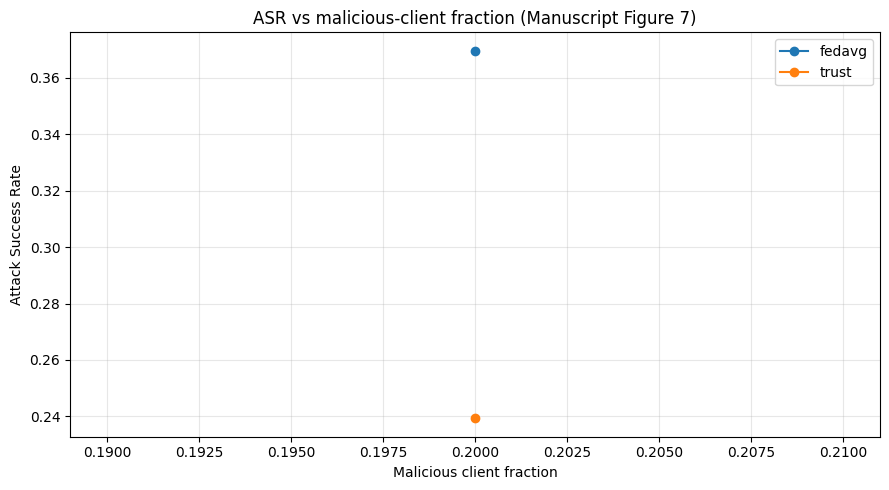

Saved ASR figure: /content/fedresvit_outputs_manuscript/figure_asr_vs_malicious_fraction.png


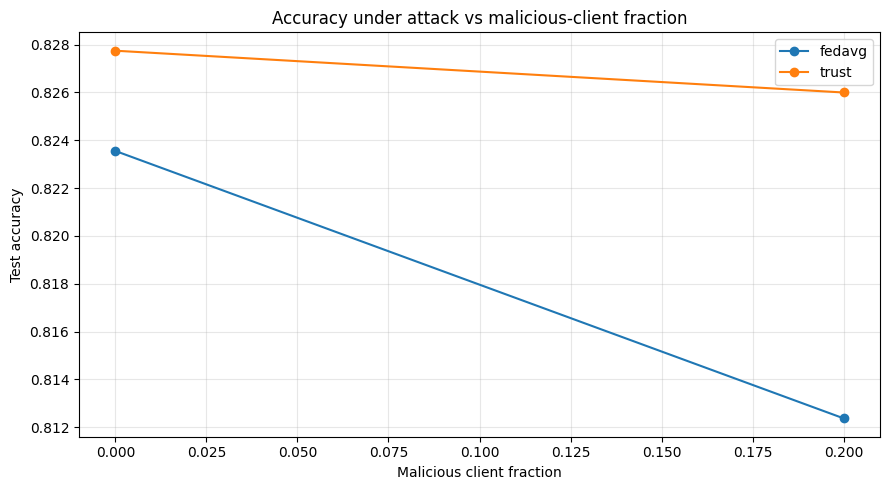

Saved accuracy figure: /content/fedresvit_outputs_manuscript/figure_accuracy_vs_malicious_fraction.png


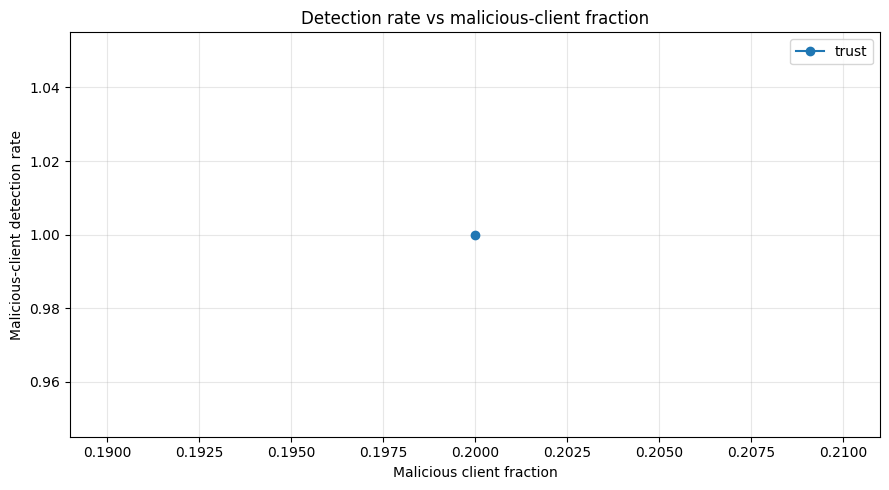

Saved detection figure: /content/fedresvit_outputs_manuscript/figure_detection_rate.png


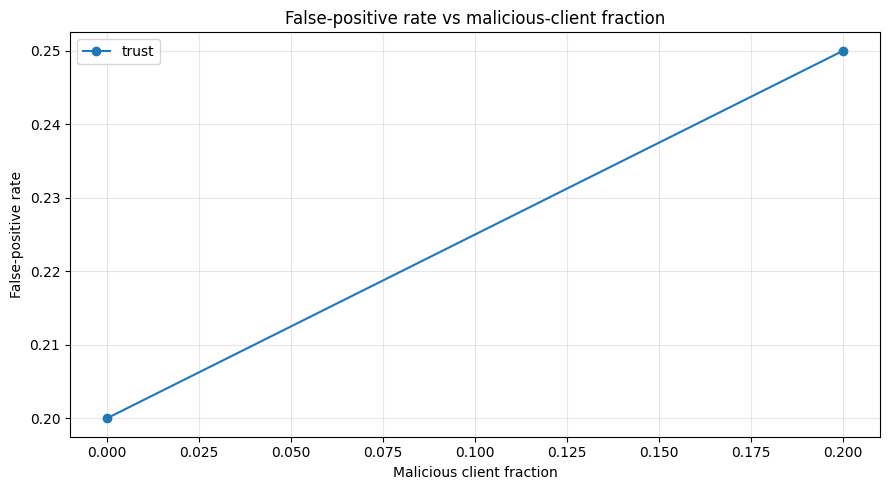

Saved FPR figure: /content/fedresvit_outputs_manuscript/figure_false_positive_rate.png


In [ ]:
plot_df = results_df.copy()
plot_df = plot_df[plot_df["aggregation"] != "centralized_upper_bound"].copy()

# ASR vs malicious fraction
attack_plot_df = plot_df[plot_df["malicious_fraction"] > 0].copy()
if len(attack_plot_df) > 0 and attack_plot_df["test_asr"].notna().any():
    plt.figure(figsize=(9, 5))
    for agg, sub in attack_plot_df.groupby("aggregation"):
        sub_mean = sub.groupby("malicious_fraction")["test_asr"].mean().sort_index()
        plt.plot(sub_mean.index, sub_mean.values, marker="o", label=agg)
    plt.xlabel("Malicious client fraction")
    plt.ylabel("Attack Success Rate")
    plt.title("ASR vs malicious-client fraction (Manuscript Figure 7)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    fig_path = os.path.join(CONFIG["OUTPUT_DIR"], "figure_asr_vs_malicious_fraction.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved ASR figure:", fig_path)
else:
    print("No attack ASR values available to plot.")

# Accuracy under attack vs malicious fraction
plt.figure(figsize=(9, 5))
for agg, sub in plot_df.groupby("aggregation"):
    sub_mean = sub.groupby("malicious_fraction")["test_accuracy"].mean().sort_index()
    plt.plot(sub_mean.index, sub_mean.values, marker="o", label=agg)
plt.xlabel("Malicious client fraction")
plt.ylabel("Test accuracy")
plt.title("Accuracy under attack vs malicious-client fraction")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
fig_path = os.path.join(CONFIG["OUTPUT_DIR"], "figure_accuracy_vs_malicious_fraction.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved accuracy figure:", fig_path)

# Detection rate vs malicious fraction
if "test_detection_rate" in attack_plot_df.columns and attack_plot_df["test_detection_rate"].notna().any():
    plt.figure(figsize=(9, 5))
    for agg, sub in attack_plot_df.groupby("aggregation"):
        if sub["test_detection_rate"].notna().any():
            sub_mean = sub.groupby("malicious_fraction")["test_detection_rate"].mean().sort_index()
            plt.plot(sub_mean.index, sub_mean.values, marker="o", label=agg)
    plt.xlabel("Malicious client fraction")
    plt.ylabel("Malicious-client detection rate")
    plt.title("Detection rate vs malicious-client fraction")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    fig_path = os.path.join(CONFIG["OUTPUT_DIR"], "figure_detection_rate.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved detection figure:", fig_path)
else:
    print("No detection-rate values available to plot.")

# FPR vs malicious fraction
if "test_false_positive_rate" in plot_df.columns and plot_df["test_false_positive_rate"].notna().any():
    plt.figure(figsize=(9, 5))
    for agg, sub in plot_df.groupby("aggregation"):
        if sub["test_false_positive_rate"].notna().any():
            sub_mean = sub.groupby("malicious_fraction")["test_false_positive_rate"].mean().sort_index()
            plt.plot(sub_mean.index, sub_mean.values, marker="o", label=agg)
    plt.xlabel("Malicious client fraction")
    plt.ylabel("False-positive rate")
    plt.title("False-positive rate vs malicious-client fraction")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    fig_path = os.path.join(CONFIG["OUTPUT_DIR"], "figure_false_positive_rate.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved FPR figure:", fig_path)


## 25. Statistical comparison across seeds (Manuscript Table 5)

Manuscript §5.5:
> "Pairwise differences between the proposed trust-aware aggregator and each
>  baseline assessed using paired Student's t-tests, or Wilcoxon signed-rank
>  tests where normality assumptions are not satisfied, with significance
>  evaluated at α = 0.05."


In [ ]:
from scipy.stats import ttest_rel, wilcoxon


def paired_compare(results_df, metric="test_macro_f1", proposed="trust", attack_only=False):
    df = results_df.copy()
    if attack_only:
        df = df[df["malicious_fraction"] > 0].copy()

    rows = []
    baselines = [a for a in df["aggregation"].dropna().unique()
                 if a not in [proposed, "centralized_upper_bound"]]

    for mal in sorted(df["malicious_fraction"].dropna().unique()):
        for baseline in baselines:
            prop = df[(df["aggregation"] == proposed) & (df["malicious_fraction"] == mal)][["seed", metric]]
            base = df[(df["aggregation"] == baseline) & (df["malicious_fraction"] == mal)][["seed", metric]]
            merged = prop.merge(base, on="seed", suffixes=("_proposed", "_baseline"))
            merged = merged.dropna()

            if len(merged) < 2:
                rows.append({
                    "malicious_fraction": mal,
                    "comparison": f"{proposed} vs {baseline}",
                    "metric": metric,
                    "n_pairs": len(merged),
                    "mean_diff": np.nan if len(merged) == 0 else float((merged[f"{metric}_proposed"] - merged[f"{metric}_baseline"]).mean()),
                    "paired_t_p": "need >=2 seeds",
                    "wilcoxon_p": "need >=2 seeds",
                })
                continue

            diffs = merged[f"{metric}_proposed"] - merged[f"{metric}_baseline"]
            try:
                t_p = float(ttest_rel(merged[f"{metric}_proposed"], merged[f"{metric}_baseline"]).pvalue)
            except Exception:
                t_p = np.nan
            try:
                w_p = float(wilcoxon(diffs).pvalue)
            except Exception:
                w_p = np.nan

            rows.append({
                "malicious_fraction": mal,
                "comparison": f"{proposed} vs {baseline}",
                "metric": metric,
                "n_pairs": len(merged),
                "mean_diff": float(diffs.mean()),
                "paired_t_p": t_p,
                "wilcoxon_p": w_p,
            })

    return pd.DataFrame(rows)


stats_f1_df = paired_compare(results_df, metric="test_macro_f1", proposed="trust", attack_only=False)
display(stats_f1_df)
stats_f1_csv = os.path.join(CONFIG["OUTPUT_DIR"], "fedresvit_paired_stats_macro_f1.csv")
stats_f1_df.to_csv(stats_f1_csv, index=False)
print("Saved macro-F1 stats:", stats_f1_csv)

if "test_asr" in results_df.columns:
    stats_asr_df = paired_compare(results_df, metric="test_asr", proposed="trust", attack_only=True)
    display(stats_asr_df)
    stats_asr_csv = os.path.join(CONFIG["OUTPUT_DIR"], "fedresvit_paired_stats_asr.csv")
    stats_asr_df.to_csv(stats_asr_csv, index=False)
    print("Saved ASR stats:", stats_asr_csv)


,malicious_fraction,comparison,metric,n_pairs,mean_diff,paired_t_p,wilcoxon_p
0,0.0,trust vs fedavg,test_macro_f1,2,0.005481,0.700831,1.0
1,0.2,trust vs fedavg,test_macro_f1,2,0.021891,0.007335,0.5


Saved macro-F1 stats: /content/fedresvit_outputs_manuscript/fedresvit_paired_stats_macro_f1.csv


,malicious_fraction,comparison,metric,n_pairs,mean_diff,paired_t_p,wilcoxon_p
0,0.2,trust vs fedavg,test_asr,2,-0.130357,0.145658,0.5


Saved ASR stats: /content/fedresvit_outputs_manuscript/fedresvit_paired_stats_asr.csv


## 26. Save final outputs

Lists every artifact produced under `CONFIG["OUTPUT_DIR"]` and saves the
active configuration for reproducibility.


In [ ]:
print("Output directory:", CONFIG["OUTPUT_DIR"])
print("Generated files:")
for p in sorted(glob.glob(os.path.join(CONFIG["OUTPUT_DIR"], "*"))):
    print(" -", p)

config_path = os.path.join(CONFIG["OUTPUT_DIR"], "active_config.txt")
with open(config_path, "w", encoding="utf-8") as f:
    f.write(f"EXPERIMENT_PROFILE={EXPERIMENT_PROFILE}\n")
    for k, v in CONFIG.items():
        f.write(f"{k}: {v}\n")
print("Saved config:", config_path)

# ---- Mirror everything to Google Drive (Colab only) ----------------------
# If you mounted Drive in cell 1, this copies the entire OUTPUT_DIR to
# /content/drive/MyDrive/fedresvit_outputs_manuscript/ so your trained
# models, CSVs, and figures survive Colab session resets.
try:
    _drive_target = DRIVE_OUTPUT_DIR if 'DRIVE_OUTPUT_DIR' in globals() else None
except NameError:
    _drive_target = None

if _drive_target:
    import shutil
    print(f"\nMirroring outputs to Google Drive: {_drive_target}")
    os.makedirs(_drive_target, exist_ok=True)
    for p in glob.glob(os.path.join(CONFIG["OUTPUT_DIR"], "*")):
        dest = os.path.join(_drive_target, os.path.basename(p))
        try:
            if os.path.isdir(p):
                if os.path.exists(dest):
                    shutil.rmtree(dest)
                shutil.copytree(p, dest)
            else:
                shutil.copy2(p, dest)
        except Exception as e:
            print(f"  failed to copy {p}: {e}")
    print("Drive mirror complete.")
else:
    print("Drive not mounted -- skipping mirror step (outputs remain in CONFIG['OUTPUT_DIR']).")


Output directory: /content/fedresvit_outputs_manuscript
Generated files:
 - /content/fedresvit_outputs_manuscript/fedavg_mal0p0_seed42.pt
 - /content/fedresvit_outputs_manuscript/fedavg_mal0p0_seed42_classification_report.csv
 - /content/fedresvit_outputs_manuscript/fedavg_mal0p0_seed42_predictions.npz
 - /content/fedresvit_outputs_manuscript/fedavg_mal0p0_seed43.pt
 - /content/fedresvit_outputs_manuscript/fedavg_mal0p0_seed43_classification_report.csv
 - /content/fedresvit_outputs_manuscript/fedavg_mal0p0_seed43_predictions.npz
 - /content/fedresvit_outputs_manuscript/fedavg_mal0p2_seed42.pt
 - /content/fedresvit_outputs_manuscript/fedavg_mal0p2_seed42_classification_report.csv
 - /content/fedresvit_outputs_manuscript/fedavg_mal0p2_seed42_predictions.npz
 - /content/fedresvit_outputs_manuscript/fedavg_mal0p2_seed43.pt
 - /content/fedresvit_outputs_manuscript/fedavg_mal0p2_seed43_classification_report.csv
 - /content/fedresvit_outputs_manuscript/fedavg_mal0p2_seed43_predictions.npz
 - 

## 27. Manuscript execution checklist

1. Set `EXPERIMENT_PROFILE = "paper_full"` at the top of cell 3 (it is the default).
2. Run cells 1–27 end-to-end on a Colab GPU (T4 minimum, A100/V100 preferred).
   Expected runtime: ~10–14 hours per seed × 5 seeds. Split across multiple
   Colab sessions if needed; the Google Drive mirror in cell 26 ensures your
   results survive session resets.
3. After completion:
   - `table_clean_classification.csv` → fill manuscript Table 3.
   - `table_attack_robustness.csv`    → fill manuscript Table 4.
   - `fedresvit_paired_stats_*.csv`   → fill manuscript Table 5.
   - `figure_convergence_macro_f1.png`       → Figure 5.
   - `figure_confusion_matrix_*.png`         → Figure 6.
   - `figure_asr_vs_malicious_fraction.png`  → Figure 7 (top).
   - `figure_detection_rate.png`             → Figure 7 (middle).
   - `figure_false_positive_rate.png`        → Figure 7 (bottom).
4. Do NOT use `debug` or `smoke` numbers as paper results — they are only
   for verifying that the code path runs end-to-end.

### Trust thresholds (Sec 4.5 / Sec 6.3 ablation)

`TRUST_T_LOW` and `TRUST_T_HIGH` are the only two free hyper-parameters of
the trust-aware aggregator. Default values are `1e-2` and `1e-1` on raw
Euclidean delta norms. If the §6.3 ablation shows that detection rate is
too low or FPR too high at these defaults, sweep over:

```python
CONFIG["TRUST_T_LOW"]  in [1e-3, 1e-2, 1e-1]
CONFIG["TRUST_T_HIGH"] in [1e-2, 1e-1, 1.0]
```

re-run only the `trust` aggregator rows, and report the sensitivity in §6.3
as the manuscript anticipates.


In [ ]:
print(CONFIG["NUM_ROUNDS"])

30
